In [1]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Dec 11 00:19:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   36C    P8             19W /  370W |    2224MiB /  10240MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [4]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [6]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [8]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [9]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [10]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1259407_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,1,363897951,5897.0,CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2,1.0
1,120,363897952,178.0,CC(=O)N,0.0
2,126,363897953,1983.0,CC(=O)NC1=CC=C(C=C1)O,0.0
3,192,363897954,1989.0,CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2,0.0
4,276,363897955,67180.0,CC(=NO)C,0.0
...,...,...,...,...,...
7683,80720,363907471,43226.0,C1=CC=C(C(=C1)C(C2=CC=C(C=C2)Cl)(C3=CN=CN=C3)O)Cl,0.0
7684,80734,363907473,51605.0,CCOC(=O)NCCOC1=CC=C(C=C1)OC2=CC=CC=C2,0.0
7685,80762,363907474,9576412.0,CC1=NN(C(=C1/C=N/OCC2=CC=C(C=C2)C(=O)OC(C)(C)C...,0.0
7686,80765,363907475,8292.0,CCOP(=S)(OCC)OC1=CC=C(C=C1)S(=O)C,0.0


In [11]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 0it [00:00, ?it/s]
Parsing SMILES: 768it [00:00, 7678.29it/s]
Parsing SMILES: 1536it [00:00, 7545.13it/s]
Parsing SMILES: 2291it [00:00, 6835.48it/s]
Parsing SMILES: 3001it [00:00, 6932.57it/s]
Parsing SMILES: 3700it [00:00, 6787.77it/s]
Parsing SMILES: 4394it [00:00, 6836.75it/s]
Parsing SMILES: 5080it [00:00, 6757.92it/s]
Parsing SMILES: 5758it [00:00, 6722.72it/s]
Parsing SMILES: 6459it [00:00, 6809.86it/s]
Parsing SMILES: 7688it [00:01, 6802.01it/s]

Generating signatures:   0%|                                                                    | 0/61 [00:00<?, ?it/s]

1/1 [==============================] - 0s 55ms/step



Generating signatures:   2%|▉                                                           | 1/61 [00:00<00:24,  2.46it/s]

1/1 [==============================] - 0s 23ms/step



Generating signatures:   3%|█▉                                                          | 2/61 [00:00<00:19,  3.04it/s]

...

1/1 [==============================] - 0s 24ms/step



Generating signatures:  98%|██████████████████████████████████████████████████████████ | 60/61 [00:16<00:00,  3.64it/s]

1/1 [==============================] - 0s 49ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [08:00<00:00, 96.17s/it]


Handling missing values


In [12]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1259407.csv')
# 打印查看结果
print(data)

                                                 smiles      A1_0      A1_1  \
0                    CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2 -0.100804  0.096188   
1                                               CC(=O)N -0.096465  0.053733   
2                                 CC(=O)NC1=CC=C(C=C1)O -0.094766  0.099283   
3           CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2  0.082643  0.102964   
4                                              CC(=NO)C -0.096225  0.070780   
...                                                 ...       ...       ...   
7683  C1=CC=C(C(=C1)C(C2=CC=C(C=C2)Cl)(C3=CN=CN=C3)O)Cl  0.050554  0.102421   
7684              CCOC(=O)NCCOC1=CC=C(C=C1)OC2=CC=CC=C2  0.073143  0.105430   
7685  CC1=NN(C(=C1/C=N/OCC2=CC=C(C=C2)C(=O)OC(C)(C)C... -0.102260 -0.094306   
7686                  CCOP(=S)(OCC)OC1=CC=C(C=C1)S(=O)C  0.095104  0.095756   
7687  C1=C(C=C(C(=C1Cl)N2C(=C(C(=N2)C#N)S(=O)C(F)(F)...  0.034396  0.019357   

          A1_2      A1_3      A1_4      A1_5      A

In [13]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2,-0.100800,0.096205,-0.101666,0.013622,0.045533,0.103638,0.100818,-0.085028,-0.027932,...,0.077215,-0.060099,0.000407,0.024521,-0.008713,0.052200,0.073152,-0.119952,0.076824,1.0
1,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,0.0
2,CC(=O)NC1=CC=C(C=C1)O,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,...,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499,0.0
3,CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2,0.082662,0.102963,0.096697,0.088996,0.102963,0.102961,0.098535,-0.102962,-0.102963,...,0.040878,-0.093784,0.035378,-0.097579,0.009945,-0.008528,-0.013349,-0.078162,-0.111090,0.0
4,CC(=NO)C,-0.096225,0.070796,0.064892,0.091473,-0.093061,0.077097,0.088396,-0.096911,-0.096889,...,-0.055854,0.063072,0.029263,0.087089,0.052258,0.060351,-0.020115,0.083724,0.063224,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7683,C1=CC=C(C(=C1)C(C2=CC=C(C=C2)Cl)(C3=CN=CN=C3)O)Cl,0.050551,0.102426,-0.099660,-0.098485,-0.107214,0.085093,0.108473,-0.102509,-0.107991,...,-0.116790,-0.091026,-0.002655,-0.099866,-0.116036,-0.018843,-0.117772,-0.121155,0.066548,0.0
7684,CCOC(=O)NCCOC1=CC=C(C=C1)OC2=CC=CC=C2,0.073188,0.105431,-0.040435,0.075106,-0.086526,0.105199,0.103438,-0.105303,-0.103506,...,-0.018075,0.095330,0.078552,-0.063007,-0.046275,-0.035554,-0.132552,0.090953,-0.086539,0.0
7685,CC1=NN(C(=C1/C=N/OCC2=CC=C(C=C2)C(=O)OC(C)(C)C...,-0.102254,-0.094302,-0.093187,-0.067410,-0.060660,-0.104566,-0.104565,0.094424,-0.102475,...,0.043983,-0.046289,-0.053898,0.131852,0.116559,0.021459,0.119129,0.068994,-0.033954,0.0
7686,CCOP(=S)(OCC)OC1=CC=C(C=C1)S(=O)C,0.095105,0.095757,0.095757,0.093176,0.092714,0.095747,0.095731,-0.095757,-0.095755,...,-0.074568,-0.122869,0.049453,-0.041374,-0.121854,0.130615,0.103142,0.044125,0.107396,0.0


In [14]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [15]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [16]:
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [17]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [18]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1259407')

In [19]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao/AID_1259407/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [20]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2,-0.100800,0.096205,-0.101666,0.013622,0.045533,0.103638,0.100818,-0.085028,-0.027932,...,0.077215,-0.060099,0.000407,0.024521,-0.008713,0.052200,0.073152,-0.119952,0.076824,1.0
1,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,0.0
2,CC(=O)NC1=CC=C(C=C1)O,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,...,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499,0.0
3,CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2,0.082662,0.102963,0.096697,0.088996,0.102963,0.102961,0.098535,-0.102962,-0.102963,...,0.040878,-0.093784,0.035378,-0.097579,0.009945,-0.008528,-0.013349,-0.078162,-0.111090,0.0
4,CC(=NO)C,-0.096225,0.070796,0.064892,0.091473,-0.093061,0.077097,0.088396,-0.096911,-0.096889,...,-0.055854,0.063072,0.029263,0.087089,0.052258,0.060351,-0.020115,0.083724,0.063224,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7683,C1=CC=C(C(=C1)C(C2=CC=C(C=C2)Cl)(C3=CN=CN=C3)O)Cl,0.050551,0.102426,-0.099660,-0.098485,-0.107214,0.085093,0.108473,-0.102509,-0.107991,...,-0.116790,-0.091026,-0.002655,-0.099866,-0.116036,-0.018843,-0.117772,-0.121155,0.066548,0.0
7684,CCOC(=O)NCCOC1=CC=C(C=C1)OC2=CC=CC=C2,0.073188,0.105431,-0.040435,0.075106,-0.086526,0.105199,0.103438,-0.105303,-0.103506,...,-0.018075,0.095330,0.078552,-0.063007,-0.046275,-0.035554,-0.132552,0.090953,-0.086539,0.0
7685,CC1=NN(C(=C1/C=N/OCC2=CC=C(C=C2)C(=O)OC(C)(C)C...,-0.102254,-0.094302,-0.093187,-0.067410,-0.060660,-0.104566,-0.104565,0.094424,-0.102475,...,0.043983,-0.046289,-0.053898,0.131852,0.116559,0.021459,0.119129,0.068994,-0.033954,0.0
7686,CCOP(=S)(OCC)OC1=CC=C(C=C1)S(=O)C,0.095105,0.095757,0.095757,0.093176,0.092714,0.095747,0.095731,-0.095757,-0.095755,...,-0.074568,-0.122869,0.049453,-0.041374,-0.121854,0.130615,0.103142,0.044125,0.107396,0.0


In [21]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
5487,C1C(NCC2=C1C3=CC=CC=C3N2)C(=O)O,0.099675,0.086845,0.099614,-0.099671,-0.099676,-0.099566,0.099679,-0.091969,-0.099631,...,0.089876,-0.087100,0.112627,0.129849,-0.039687,-0.061787,0.050958,-0.045976,0.115329,0.0
2408,CC(=O)NC1=C(C2=C(C=C1)C3=CC=CC=C3C2)OC(=O)C4=C...,0.096386,-0.077745,-0.105071,0.104756,-0.084605,0.086927,-0.083651,0.021812,0.091526,...,0.005614,-0.107789,0.117184,-0.027837,-0.124242,0.150247,-0.075652,-0.115677,0.052272,0.0
7008,C1=CC=C(C=C1)CCC(=O)Cl,-0.099741,0.097308,-0.084035,0.018809,-0.099869,0.098772,0.099872,-0.099835,0.028077,...,0.006915,-0.093080,0.084938,0.023054,-0.029319,0.014535,0.061766,0.175413,0.015341,1.0
5548,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,0.089745,-0.086106,0.089821,0.086151,0.089821,-0.089795,0.083844,0.089821,0.088957,...,0.047176,0.110420,-0.076553,-0.050904,0.034649,-0.111680,0.103840,-0.073171,-0.101465,0.0
3916,CCC(=C)C(=O)C1=C(C(=C(C=C1)OCC(=O)O)Cl)Cl,-0.100246,-0.068501,-0.025723,-0.074092,-0.028661,0.080056,0.105529,-0.057569,0.095328,...,-0.109945,0.021745,-0.008664,0.100902,-0.007248,-0.138458,0.043069,0.130301,0.077331,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5690,C1CC2=C[C@H]3C(O3)C=C(C1)O2,-0.117027,0.011343,0.086195,-0.112929,-0.055716,-0.021349,0.074290,0.018193,0.099979,...,0.044568,-0.075111,-0.008442,0.002987,-0.078986,-0.138005,0.132751,-0.047460,0.129167,0.0
5409,C1[C@@H](O1)COS(=O)(=O)C2=CC=CC(=C2)[N+](=O)[O-],-0.095423,-0.094694,0.095455,-0.077000,0.095455,0.095440,-0.095455,-0.095455,-0.095455,...,0.087981,0.003870,0.133320,-0.097659,-0.028282,-0.056716,-0.046149,0.069627,-0.149190,1.0
4342,C1=CC(=CC=C1CCl)C(F)(F)F,-0.097408,-0.078942,-0.097561,-0.083984,-0.097428,0.097511,0.097562,0.011336,0.087542,...,-0.106867,-0.118155,-0.033121,0.021654,-0.019012,0.102420,-0.092894,0.084742,-0.114786,0.0
775,CN(C)C1=CC=C(C=C1)N=NC2=CC3=CC=CC=C3C=C2,-0.100163,-0.099042,-0.101346,0.093125,-0.073647,0.100953,0.098252,0.048228,0.098292,...,0.072149,-0.060705,-0.081290,-0.096487,0.059459,0.114457,0.114430,0.003786,0.002635,1.0


In [22]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [23]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [24]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

'\ndef Scoring_metrices(label, pred, truth, D):\n    score={}\n    \n    accuracy = metrics.accuracy_score(truth, label)\n    score[D+" Accuracy:"] = accuracy\n    print(D+" Accuracy:", accuracy)\n    \n    mcc_score = matthews_corrcoef(truth, label)\n    score[D+" MCC Score:"] = mcc_score\n    print(D+" MCC Score:",mcc_score)\n    \n    F1_score = f1_score(truth, label, average=\'macro\')\n    score[D+" F1 Score:"] = F1_score\n    print(D+" F1 Score:", F1_score)\n    \n    fpr, tpr, _ = roc_curve(truth, pred)\n    roc_auc = auc(fpr, tpr)\n    score[D+" AUC VALUE:"] = roc_auc\n    print(D+" AUC VALUE:",roc_auc)\n    \n    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)\n    score[D+" kappa Score:"] = kappa_rf\n    print(D+" kappa Score:",kappa_rf)\n    \n    Precision_score = metrics.precision_score(truth, label)\n    score[D+" Precision:"] = Precision_score\n    print(D+" Precision:", Precision_score)\n    \n    Recall_score = metrics.recall_score(truth, label)\n    score[D+"

In [25]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 300
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:03:04,954:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:03:04,956:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:03:04,958:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 205
After filteration
Train shape
 (5535, 205) 
Test shape
 (1384, 205)
Before Oversampling
y_train_filtered
 0.0    3203
1.0    2332
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


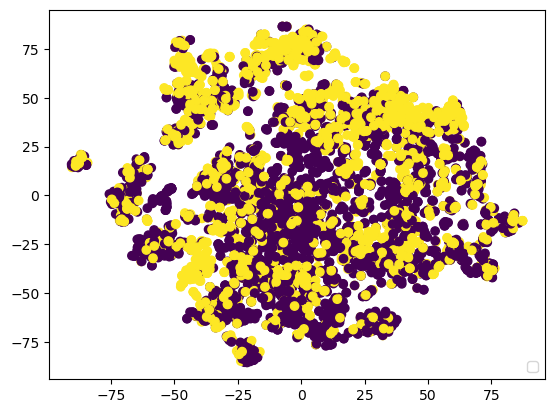

After Oversampling
Final_Ytrain
 0  
0.0    3203
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9954773869346734
Training MCC Score: 0.9909128342871031
Training F1 Score: 0.9954541315271843
Training AUC VALUE: 0.9998678732363869
Training kappa Score: 0.9909082838230849
Training Precision: 0.9935158501440923
Training Recall: 0.9967473798337549
Training Sensitivity: 0.9967473798337549
Training Specificity: 0.9943802684982829
Training CCR: 0.9954773869346734
Training PPV: 0.9935158501440923


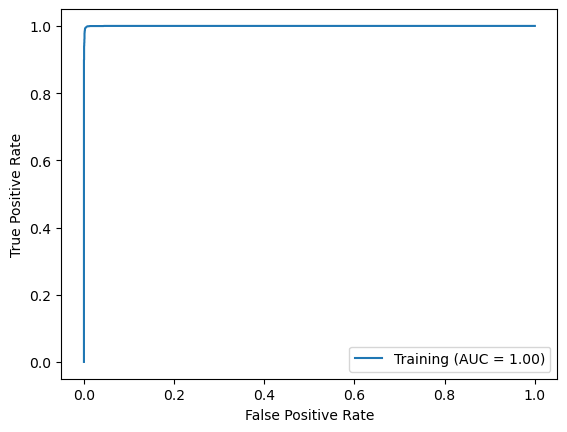

Testing Accuracy: 0.7528901734104047
Testing MCC Score: 0.49007011843389964
Testing F1 Score: 0.7425007017841638
Testing AUC VALUE: 0.8066923457548458
Testing kappa Score: 0.48670032793711937
Testing Precision: 0.7431906614785992
Testing Recall: 0.6452702702702703
Testing Sensitivity: 0.6452702702702703
Testing Specificity: 0.8333333333333334
Testing CCR: 0.7528901734104047
Testing PPV: 0.7431906614785992


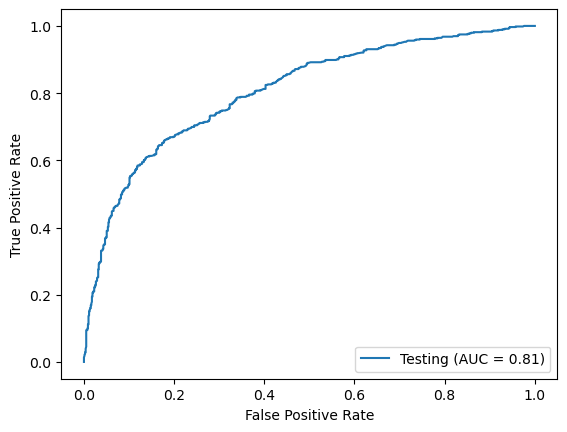

Fold # 1 Random Seed: 317
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:07:47,448:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:07:47,451:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:07:47,452:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 215
After filteration
Train shape
 (5535, 215) 
Test shape
 (1384, 215)
Before Oversampling
y_train_filtered
 0.0    3208
1.0    2327
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


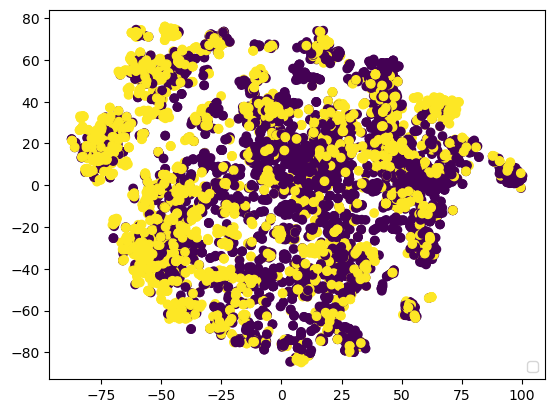

After Oversampling
Final_Ytrain
 0  
0.0    3208
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.99581589958159
Training MCC Score: 0.9915927425687601
Training F1 Score: 0.9957916025828107
Training AUC VALUE: 0.9999626543507513
Training kappa Score: 0.9915832452403146
Training Precision: 0.9978213507625272
Training Recall: 0.9931333574268161
Training Sensitivity: 0.9931333574268161
Training Specificity: 0.9981296758104738
Training CCR: 0.99581589958159
Training PPV: 0.9978213507625272


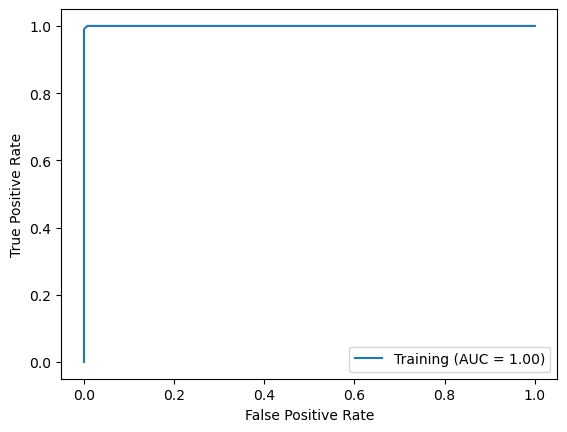

Testing Accuracy: 0.7608381502890174
Testing MCC Score: 0.5086612879890691
Testing F1 Score: 0.7484613226283447
Testing AUC VALUE: 0.8088802760094416
Testing kappa Score: 0.5006757876195709
Testing Precision: 0.7770833333333333
Testing Recall: 0.6247906197654941
Testing Sensitivity: 0.6247906197654941
Testing Specificity: 0.8640406607369758
Testing CCR: 0.7608381502890174
Testing PPV: 0.7770833333333333


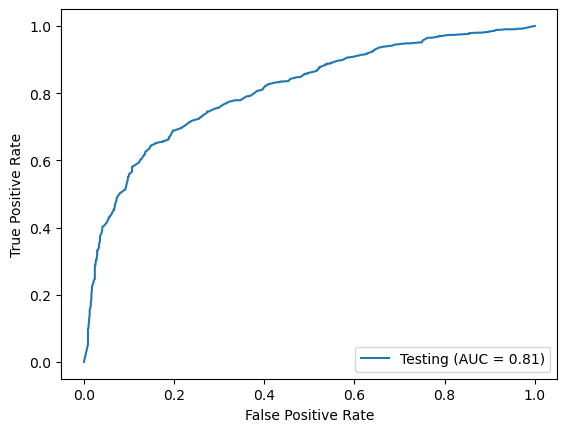

Fold # 2 Random Seed: 18
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:11:16,707:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:11:16,710:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:11:16,711:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 205
After filteration
Train shape
 (5535, 205) 
Test shape
 (1384, 205)
Before Oversampling
y_train_filtered
 0.0    3201
1.0    2334
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


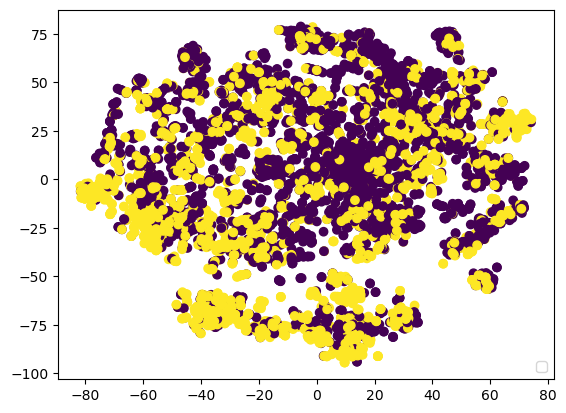

After Oversampling
Final_Ytrain
 0  
0.0    3201
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.996313672922252
Training MCC Score: 0.9925966547052656
Training F1 Score: 0.9962927825364126
Training AUC VALUE: 0.9999712662073551
Training kappa Score: 0.992585606105355
Training Precision: 0.998547039593171
Training Recall: 0.9934947596675099
Training Sensitivity: 0.9934947596675099
Training Specificity: 0.9987503905029679
Training CCR: 0.996313672922252
Training PPV: 0.998547039593171


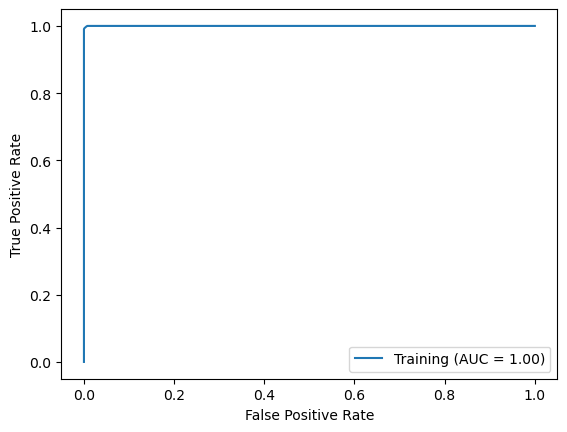

Testing Accuracy: 0.7485549132947977
Testing MCC Score: 0.4801344019928823
Testing F1 Score: 0.7368407249075507
Testing AUC VALUE: 0.7950444008026297
Testing kappa Score: 0.4758990519800472
Testing Precision: 0.7410358565737052
Testing Recall: 0.6305084745762712
Testing Sensitivity: 0.6305084745762712
Testing Specificity: 0.836272040302267
Testing CCR: 0.7485549132947977
Testing PPV: 0.7410358565737052


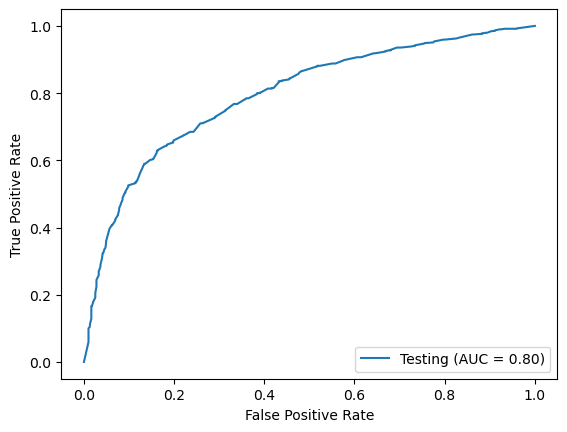

Fold # 3 Random Seed: 848
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:15:29,575:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:15:29,578:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:15:29,579:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 220
After filteration
Train shape
 (5535, 220) 
Test shape
 (1384, 220)
Before Oversampling
y_train_filtered
 0.0    3195
1.0    2340
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


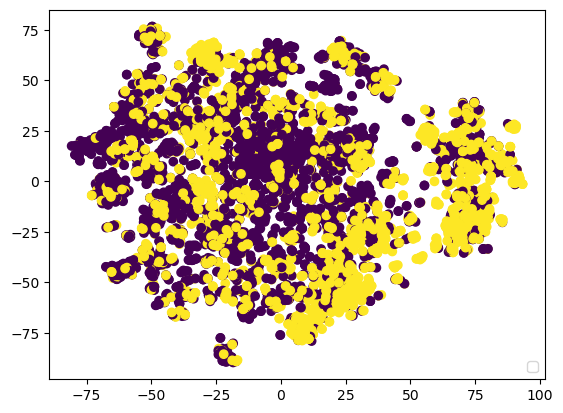

After Oversampling
Final_Ytrain
 0  
0.0    3195
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9953035893995303
Training MCC Score: 0.9905619197855544
Training F1 Score: 0.9952799417315852
Training AUC VALUE: 0.9999183875691202
Training kappa Score: 0.9905598930721391
Training Precision: 0.993869455463397
Training Recall: 0.9960245753523672
Training Sensitivity: 0.9960245753523672
Training Specificity: 0.994679186228482
Training CCR: 0.9953035893995303
Training PPV: 0.993869455463397


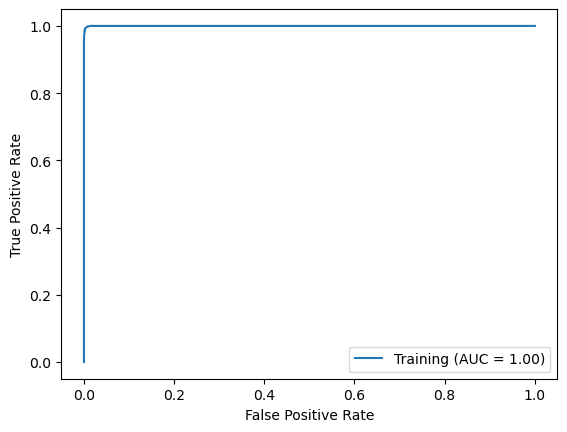

Testing Accuracy: 0.7456647398843931
Testing MCC Score: 0.4731069133561564
Testing F1 Score: 0.7349714825380869
Testing AUC VALUE: 0.7934835188356164
Testing kappa Score: 0.4710491114083699
Testing Precision: 0.7222222222222222
Testing Recall: 0.6455479452054794
Testing Sensitivity: 0.6455479452054794
Testing Specificity: 0.81875
Testing CCR: 0.7456647398843931
Testing PPV: 0.7222222222222222


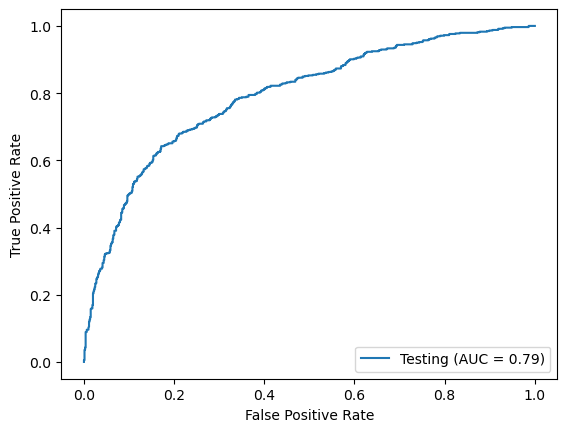

Fold # 4 Random Seed: 126
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:21:01,800:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:21:01,803:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:21:01,804:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 209
After filteration
Train shape
 (5535, 209) 
Test shape
 (1384, 209)
Before Oversampling
y_train_filtered
 0.0    3189
1.0    2346
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


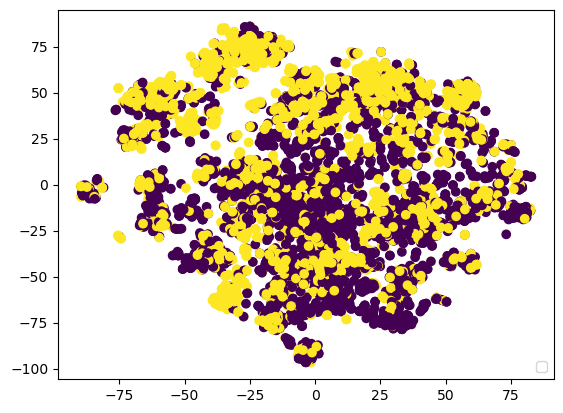

After Oversampling
Final_Ytrain
 0  
0.0    3189
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9959704499664204
Training MCC Score: 0.9919002380223035
Training F1 Score: 0.9959501190111517
Training AUC VALUE: 0.9999605619379863
Training kappa Score: 0.9919002380223035
Training Precision: 0.9956631731116733
Training Recall: 0.9956631731116733
Training Sensitivity: 0.9956631731116733
Training Specificity: 0.9962370649106302
Training CCR: 0.9959704499664204
Training PPV: 0.9956631731116733


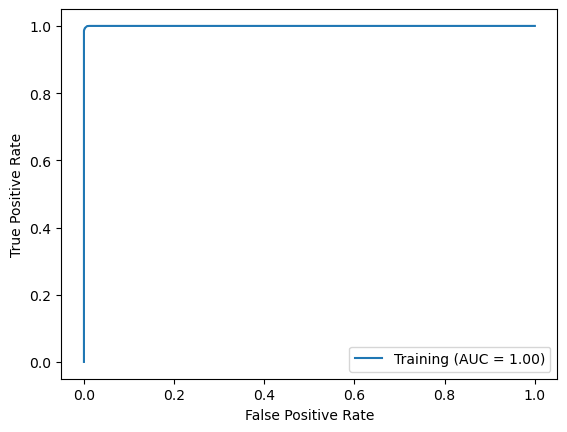

Testing Accuracy: 0.763728323699422
Testing MCC Score: 0.5087043057448845
Testing F1 Score: 0.7523224829483917
Testing AUC VALUE: 0.8133720281281394
Testing kappa Score: 0.5059322885052904
Testing Precision: 0.7465618860510805
Testing Recall: 0.657439446366782
Testing Sensitivity: 0.657439446366782
Testing Specificity: 0.8399503722084367
Testing CCR: 0.763728323699422
Testing PPV: 0.7465618860510805


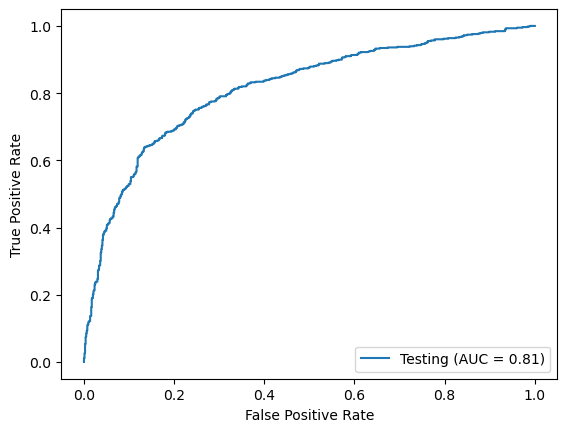

Fold # 5 Random Seed: 250
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:25:10,273:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:25:10,275:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:25:10,276:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 204
After filteration
Train shape
 (5535, 204) 
Test shape
 (1384, 204)
Before Oversampling
y_train_filtered
 0.0    3193
1.0    2342
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


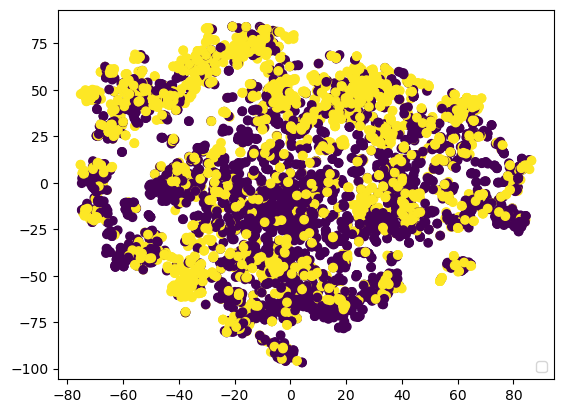

After Oversampling
Final_Ytrain
 0  
0.0    3193
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9954697986577181
Training MCC Score: 0.9908955774481951
Training F1 Score: 0.9954470811028147
Training AUC VALUE: 0.9999535372315049
Training kappa Score: 0.9908941686464249
Training Precision: 0.9942279942279942
Training Recall: 0.9960245753523672
Training Sensitivity: 0.9960245753523672
Training Specificity: 0.9949890385217663
Training CCR: 0.9954697986577181
Training PPV: 0.9942279942279942


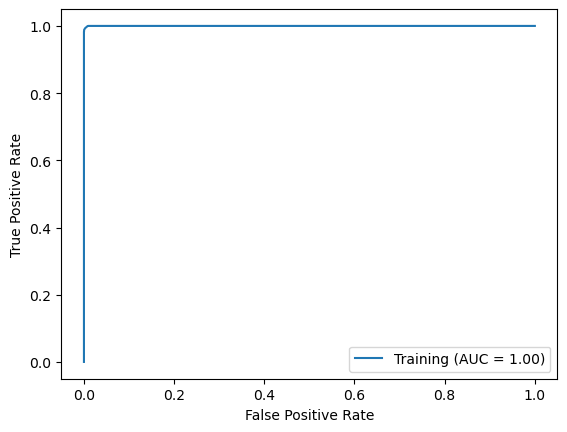

Testing Accuracy: 0.7478323699421965
Testing MCC Score: 0.47783836351724424
Testing F1 Score: 0.7379321196140187
Testing AUC VALUE: 0.8097957426022573
Testing kappa Score: 0.4765461426088162
Testing Precision: 0.7185741088180112
Testing Recall: 0.6580756013745704
Testing Sensitivity: 0.6580756013745704
Testing Specificity: 0.8129675810473815
Testing CCR: 0.7478323699421965
Testing PPV: 0.7185741088180112


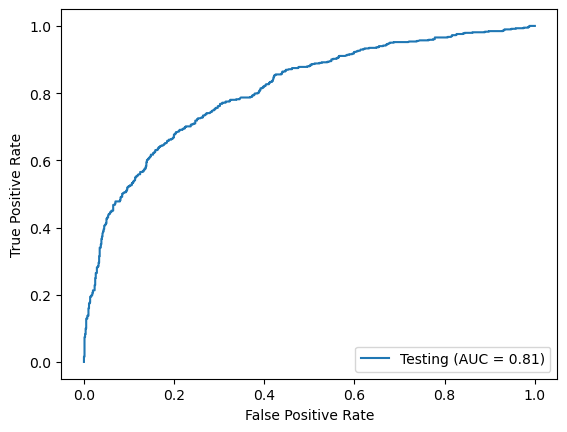

Fold # 6 Random Seed: 795
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:28:36,304:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:28:36,307:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:28:36,308:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 214
After filteration
Train shape
 (5535, 214) 
Test shape
 (1384, 214)
Before Oversampling
y_train_filtered
 0.0    3193
1.0    2342
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


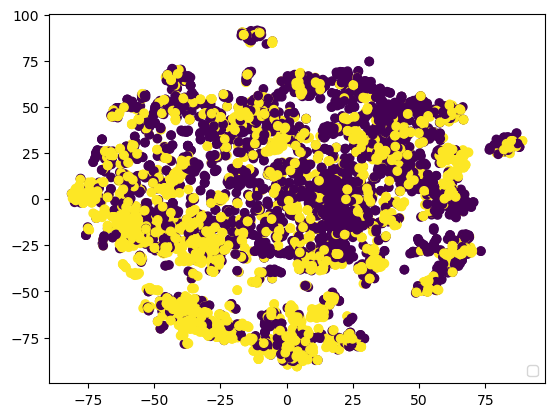

After Oversampling
Final_Ytrain
 0  
0.0    3193
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9931208053691275
Training MCC Score: 0.9861706952389958
Training F1 Score: 0.9930846413467074
Training AUC VALUE: 0.9995825141983089
Training kappa Score: 0.9861692924785991
Training Precision: 0.9934829833454019
Training Recall: 0.9916877484640405
Training Sensitivity: 0.9916877484640405
Training Specificity: 0.9943626683369872
Training CCR: 0.9931208053691275
Training PPV: 0.9934829833454019


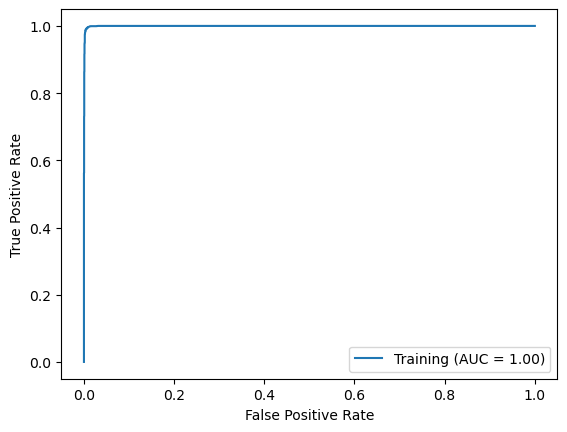

Testing Accuracy: 0.7507225433526011
Testing MCC Score: 0.4833331160698784
Testing F1 Score: 0.7403203411925751
Testing AUC VALUE: 0.8232222279353163
Testing kappa Score: 0.4815567629545662
Testing Precision: 0.7257142857142858
Testing Recall: 0.654639175257732
Testing Sensitivity: 0.654639175257732
Testing Specificity: 0.8204488778054863
Testing CCR: 0.7507225433526011
Testing PPV: 0.7257142857142858


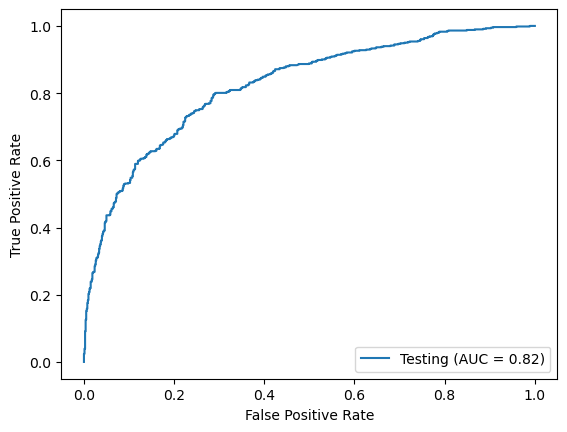

Fold # 7 Random Seed: 820
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:32:02,381:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:32:02,384:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:32:02,385:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 207
After filteration
Train shape
 (5535, 207) 
Test shape
 (1384, 207)
Before Oversampling
y_train_filtered
 0.0    3198
1.0    2337
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


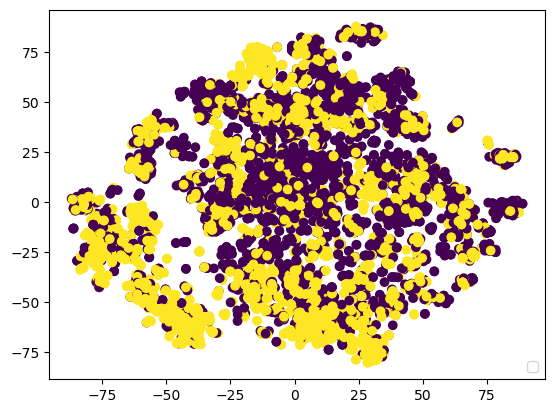

After Oversampling
Final_Ytrain
 0  
0.0    3198
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9954735959765297
Training MCC Score: 0.9908999592825611
Training F1 Score: 0.9954499513720704
Training AUC VALUE: 0.9999178990844703
Training kappa Score: 0.9908999030012324
Training Precision: 0.994942196531792
Training Recall: 0.9953017708709794
Training Sensitivity: 0.9953017708709794
Training Specificity: 0.9956222639149468
Training CCR: 0.9954735959765297
Training PPV: 0.994942196531792


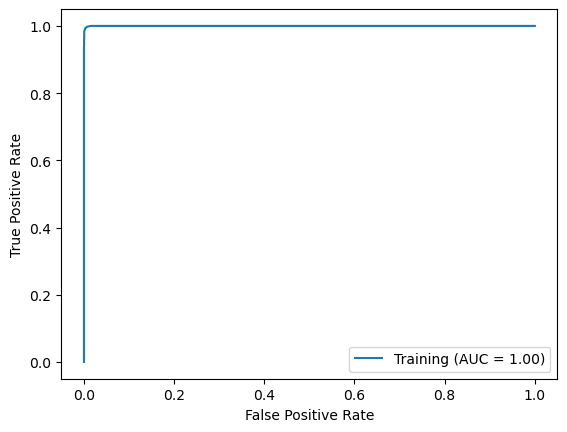

Testing Accuracy: 0.7521676300578035
Testing MCC Score: 0.4866931441672389
Testing F1 Score: 0.7398631672105456
Testing AUC VALUE: 0.8209041999491278
Testing kappa Score: 0.4820766162466942
Testing Precision: 0.7459677419354839
Testing Recall: 0.6303236797274276
Testing Sensitivity: 0.6303236797274276
Testing Specificity: 0.8419071518193224
Testing CCR: 0.7521676300578035
Testing PPV: 0.7459677419354839


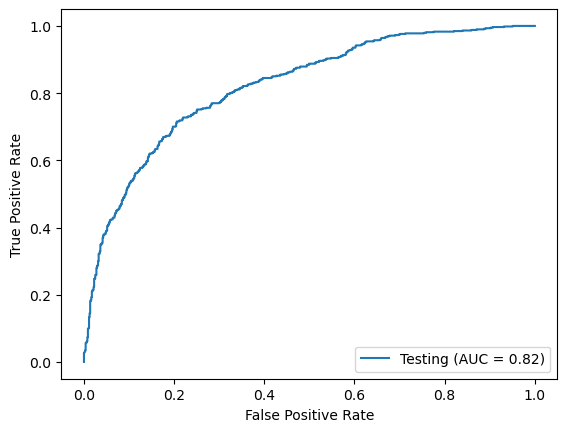

Fold # 8 Random Seed: 590
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:35:42,842:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:35:42,846:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:35:42,848:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 204
After filteration
Train shape
 (5535, 204) 
Test shape
 (1384, 204)
Before Oversampling
y_train_filtered
 0.0    3192
1.0    2343
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


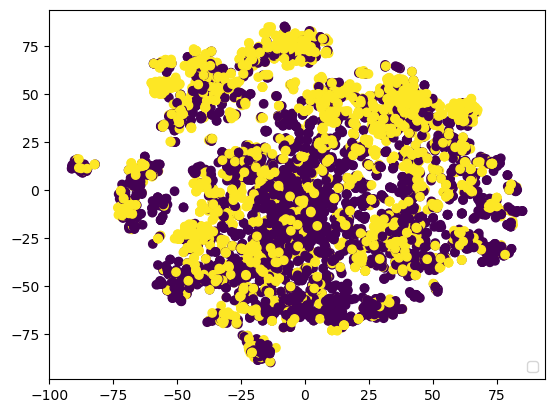

After Oversampling
Final_Ytrain
 0  
0.0    3192
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9959724786037926
Training MCC Score: 0.9919054565637757
Training F1 Score: 0.9959522750197836
Training AUC VALUE: 0.9999638258095547
Training kappa Score: 0.9919045537055222
Training Precision: 0.9949476723204619
Training Recall: 0.996385977593061
Training Sensitivity: 0.996385977593061
Training Specificity: 0.9956140350877193
Training CCR: 0.9959724786037926
Training PPV: 0.9949476723204619


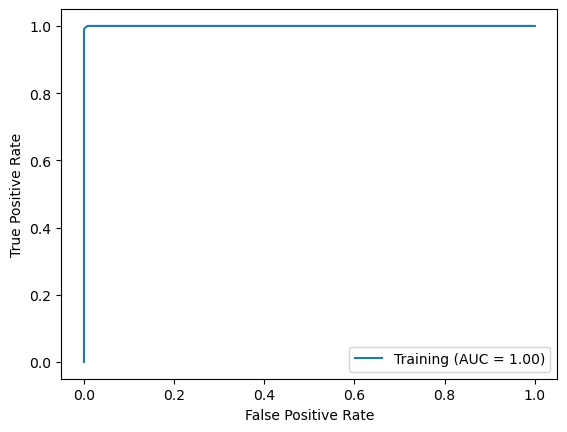

Testing Accuracy: 0.7434971098265896
Testing MCC Score: 0.46806637041322563
Testing F1 Score: 0.7327933945604759
Testing AUC VALUE: 0.8116625905865055
Testing kappa Score: 0.4664645402855542
Testing Precision: 0.714828897338403
Testing Recall: 0.6471600688468159
Testing Sensitivity: 0.6471600688468159
Testing Specificity: 0.813200498132005
Testing CCR: 0.7434971098265896
Testing PPV: 0.714828897338403


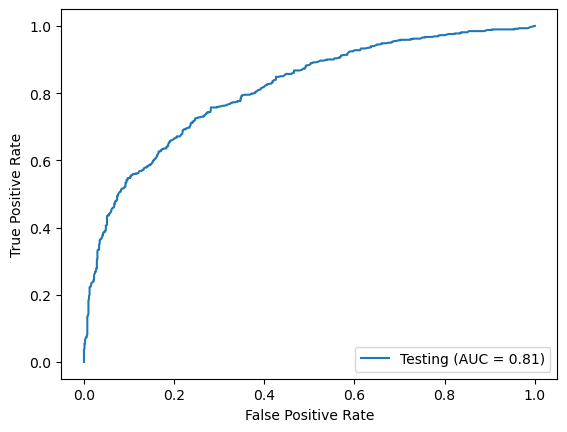

Fold # 9 Random Seed: 420
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:41:07,861:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:41:07,863:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:41:07,864:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 198
After filteration
Train shape
 (5535, 198) 
Test shape
 (1384, 198)
Before Oversampling
y_train_filtered
 0.0    3196
1.0    2339
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


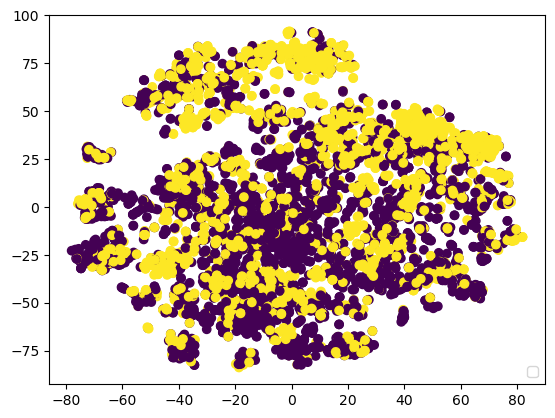

After Oversampling
Final_Ytrain
 0  
0.0    3196
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9963105819218514
Training MCC Score: 0.9925878211096397
Training F1 Score: 0.9962920993389284
Training AUC VALUE: 0.9999666415328521
Training kappa Score: 0.9925842120924613
Training Precision: 0.9945945945945946
Training Recall: 0.9974701843151428
Training Sensitivity: 0.9974701843151428
Training Specificity: 0.9953066332916145
Training CCR: 0.9963105819218514
Training PPV: 0.9945945945945946


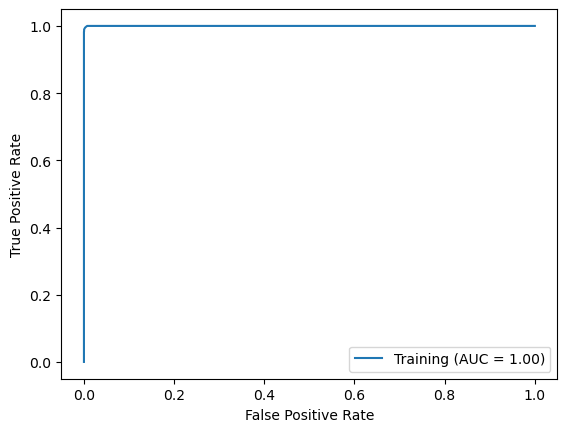

Testing Accuracy: 0.7420520231213873
Testing MCC Score: 0.46489231106577905
Testing F1 Score: 0.7295997749620057
Testing AUC VALUE: 0.7992747344436957
Testing kappa Score: 0.4612307920459552
Testing Precision: 0.7270916334661355
Testing Recall: 0.6239316239316239
Testing Sensitivity: 0.6239316239316239
Testing Specificity: 0.8285356695869838
Testing CCR: 0.7420520231213873
Testing PPV: 0.7270916334661355


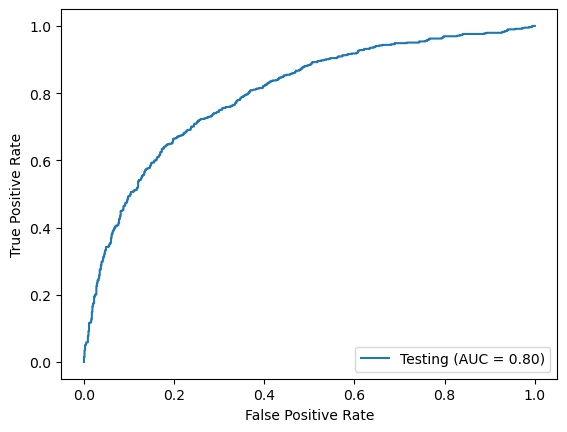

Fold # 10 Random Seed: 392
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:44:11,707:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:44:11,710:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:44:11,711:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 212
After filteration
Train shape
 (5535, 212) 
Test shape
 (1384, 212)
Before Oversampling
y_train_filtered
 0.0    3189
1.0    2346
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


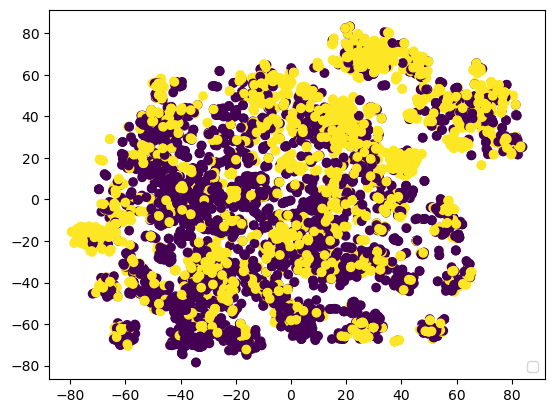

After Oversampling
Final_Ytrain
 0  
0.0    3189
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9949630624580256
Training MCC Score: 0.9898787788018472
Training F1 Score: 0.9949383698083447
Training AUC VALUE: 0.999879419258671
Training kappa Score: 0.9898767499404265
Training Precision: 0.9935088351965381
Training Recall: 0.9956631731116733
Training Sensitivity: 0.9956631731116733
Training Specificity: 0.9943555973659455
Training CCR: 0.9949630624580256
Training PPV: 0.9935088351965381


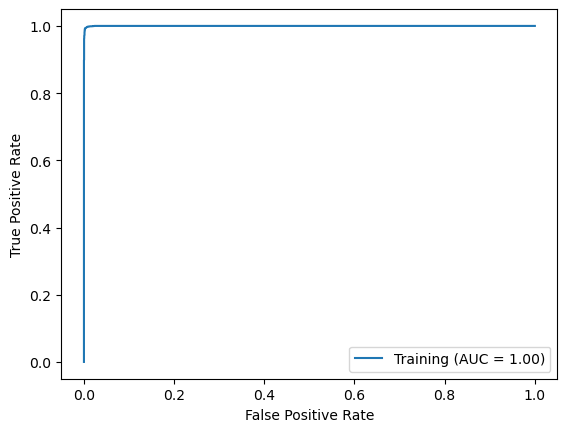

Testing Accuracy: 0.7565028901734104
Testing MCC Score: 0.4930955562919269
Testing F1 Score: 0.7439017091412452
Testing AUC VALUE: 0.8070376158053354
Testing kappa Score: 0.4895526439055995
Testing Precision: 0.7414829659318637
Testing Recall: 0.6401384083044983
Testing Sensitivity: 0.6401384083044983
Testing Specificity: 0.8399503722084367
Testing CCR: 0.7565028901734104
Testing PPV: 0.7414829659318637


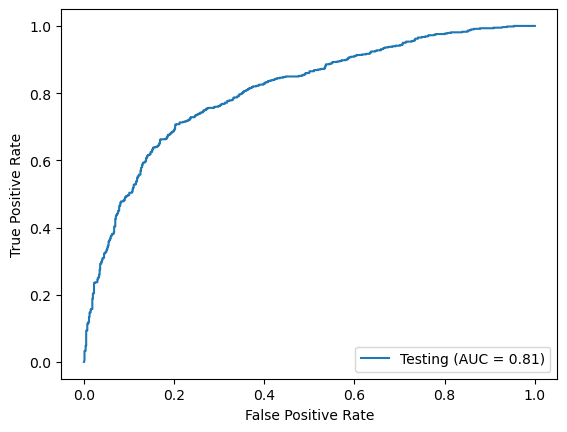

Fold # 11 Random Seed: 791
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:48:38,261:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:48:38,263:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:48:38,264:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 218
After filteration
Train shape
 (5535, 218) 
Test shape
 (1384, 218)
Before Oversampling
y_train_filtered
 0.0    3196
1.0    2339
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


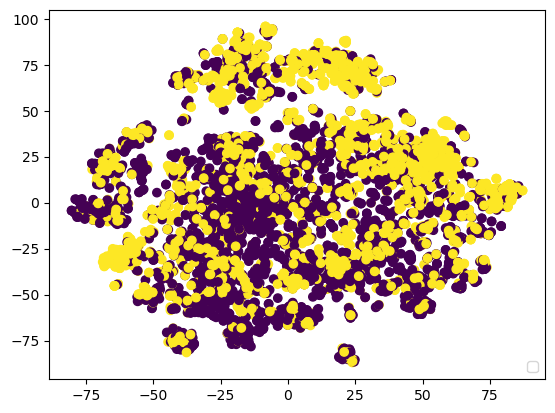

After Oversampling
Final_Ytrain
 0  
0.0    3196
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9932919671306389
Training MCC Score: 0.9865137029535607
Training F1 Score: 0.9932567385684021
Training AUC VALUE: 0.9995632867792366
Training kappa Score: 0.9865134786619281
Training Precision: 0.9931283905967451
Training Recall: 0.9924105529454282
Training Sensitivity: 0.9924105529454282
Training Specificity: 0.9940550688360451
Training CCR: 0.9932919671306389
Training PPV: 0.9931283905967451


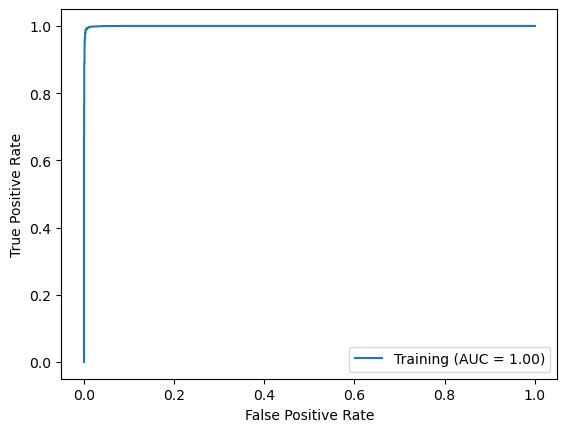

Testing Accuracy: 0.7153179190751445
Testing MCC Score: 0.4075652830418351
Testing F1 Score: 0.6994508171602551
Testing AUC VALUE: 0.7794903886268091
Testing kappa Score: 0.4024638001959293
Testing Precision: 0.6985446985446986
Testing Recall: 0.5743589743589743
Testing Sensitivity: 0.5743589743589743
Testing Specificity: 0.818523153942428
Testing CCR: 0.7153179190751445
Testing PPV: 0.6985446985446986


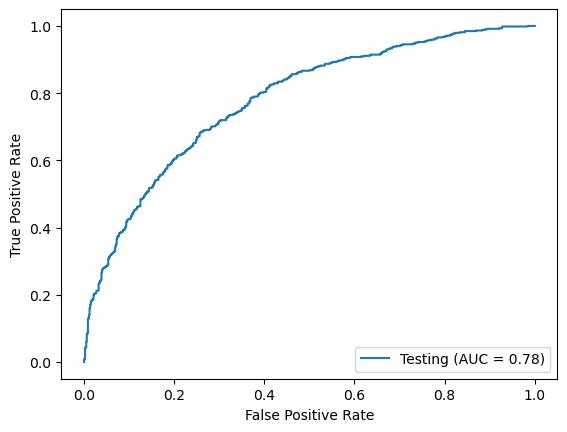

Fold # 12 Random Seed: 72
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:52:13,377:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:52:13,379:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:52:13,380:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 209
After filteration
Train shape
 (5535, 209) 
Test shape
 (1384, 209)
Before Oversampling
y_train_filtered
 0.0    3192
1.0    2343
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


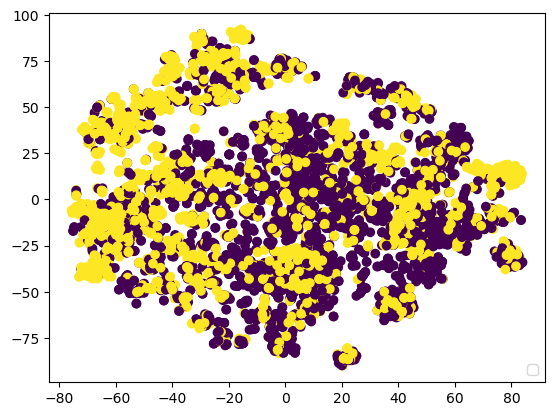

After Oversampling
Final_Ytrain
 0  
0.0    3192
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9937909045141803
Training MCC Score: 0.9875284171272184
Training F1 Score: 0.9937607894667213
Training AUC VALUE: 0.9998282433586678
Training kappa Score: 0.9875216216600149
Training Precision: 0.9913606911447084
Training Recall: 0.9953017708709794
Training Sensitivity: 0.9953017708709794
Training Specificity: 0.9924812030075187
Training CCR: 0.9937909045141803
Training PPV: 0.9913606911447084


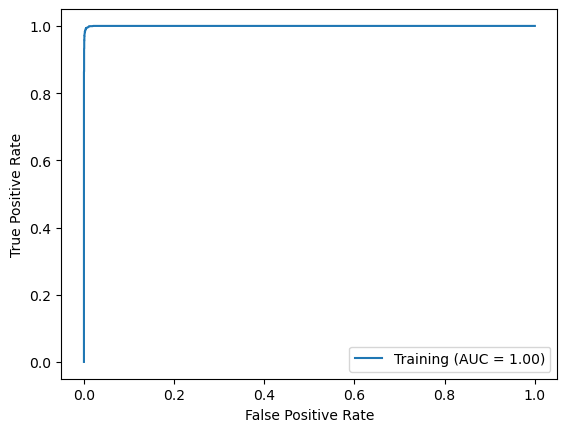

Testing Accuracy: 0.7398843930635838
Testing MCC Score: 0.45870581129380067
Testing F1 Score: 0.7261448556522198
Testing AUC VALUE: 0.8088847115914288
Testing kappa Score: 0.4546111323955996
Testing Precision: 0.7241379310344828
Testing Recall: 0.6144578313253012
Testing Sensitivity: 0.6144578313253012
Testing Specificity: 0.8306351183063512
Testing CCR: 0.7398843930635838
Testing PPV: 0.7241379310344828


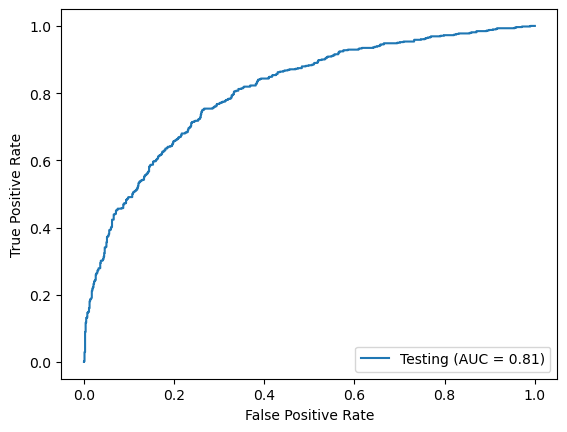

Fold # 13 Random Seed: 329
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-04 23:57:19,312:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:57:19,316:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:57:19,318:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 213
After filteration
Train shape
 (5535, 213) 
Test shape
 (1384, 213)
Before Oversampling
y_train_filtered
 0.0    3156
1.0    2379
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


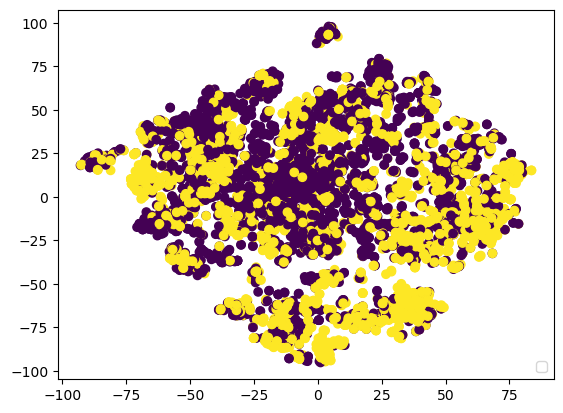

After Oversampling
Final_Ytrain
 0  
0.0    3156
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9964544994090833
Training MCC Score: 0.9928784959839562
Training F1 Score: 0.9964392193438651
Training AUC VALUE: 0.999887777504474
Training kappa Score: 0.9928784388916031
Training Precision: 0.9960260115606936
Training Recall: 0.996385977593061
Training Sensitivity: 0.996385977593061
Training Specificity: 0.9965145754119138
Training CCR: 0.9964544994090833
Training PPV: 0.9960260115606936


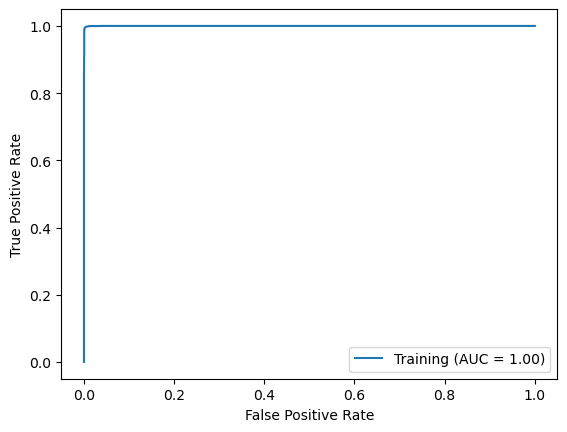

Testing Accuracy: 0.7384393063583815
Testing MCC Score: 0.4428188310486029
Testing F1 Score: 0.7196831855119366
Testing AUC VALUE: 0.7904954565833069
Testing kappa Score: 0.44064825710566324
Testing Precision: 0.6902286902286903
Testing Recall: 0.6091743119266055
Testing Sensitivity: 0.6091743119266055
Testing Specificity: 0.8224076281287247
Testing CCR: 0.7384393063583815
Testing PPV: 0.6902286902286903


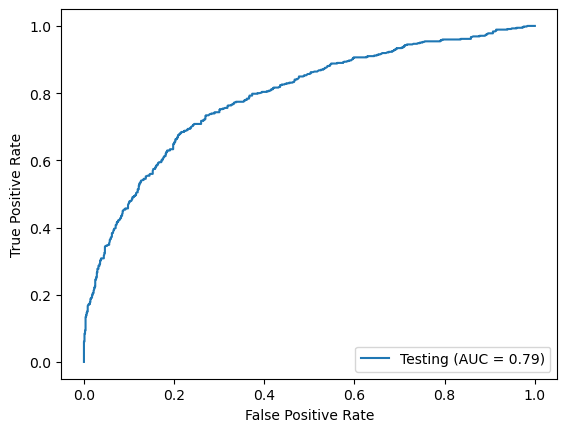

Fold # 14 Random Seed: 747
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-05 00:03:21,352:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:03:21,355:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:03:21,356:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 215
After filteration
Train shape
 (5535, 215) 
Test shape
 (1384, 215)
Before Oversampling
y_train_filtered
 0.0    3184
1.0    2351
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


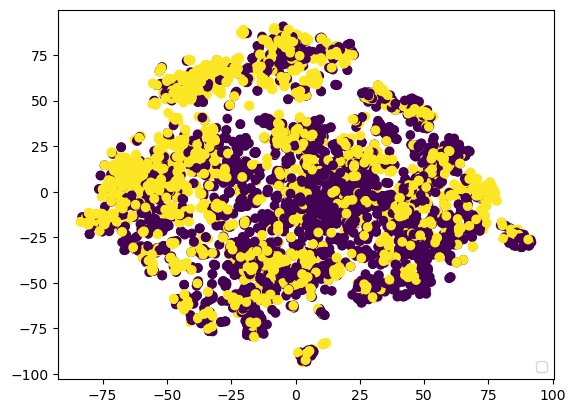

After Oversampling
Final_Ytrain
 0  
0.0    3184
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9959670643589312
Training MCC Score: 0.9918960010917911
Training F1 Score: 0.9959475462259608
Training AUC VALUE: 0.9999432471355694
Training kappa Score: 0.9918950961313873
Training Precision: 0.9949476723204619
Training Recall: 0.996385977593061
Training Sensitivity: 0.996385977593061
Training Specificity: 0.9956030150753769
Training CCR: 0.9959670643589312
Training PPV: 0.9949476723204619


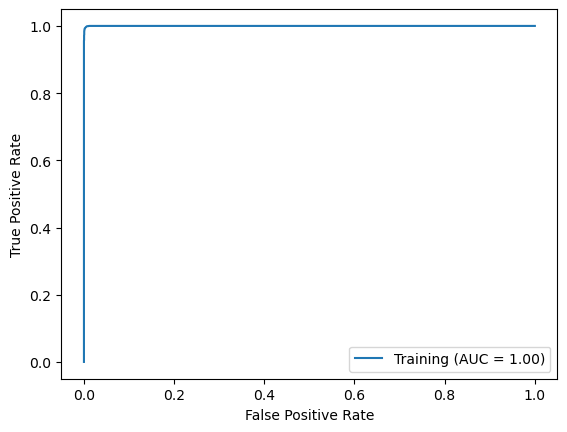

Testing Accuracy: 0.7492774566473989
Testing MCC Score: 0.4762535736930756
Testing F1 Score: 0.7357626216858772
Testing AUC VALUE: 0.8022070010307659
Testing kappa Score: 0.47315579075778114
Testing Precision: 0.7269076305220884
Testing Recall: 0.631762652705061
Testing Sensitivity: 0.631762652705061
Testing Specificity: 0.8323057953144266
Testing CCR: 0.7492774566473989
Testing PPV: 0.7269076305220884


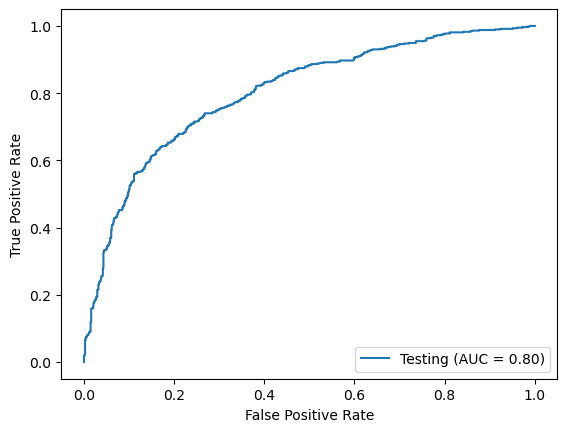

Fold # 15 Random Seed: 698
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-05 00:07:07,393:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:07:07,395:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:07:07,397:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 216
After filteration
Train shape
 (5535, 216) 
Test shape
 (1384, 216)
Before Oversampling
y_train_filtered
 0.0    3217
1.0    2318
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


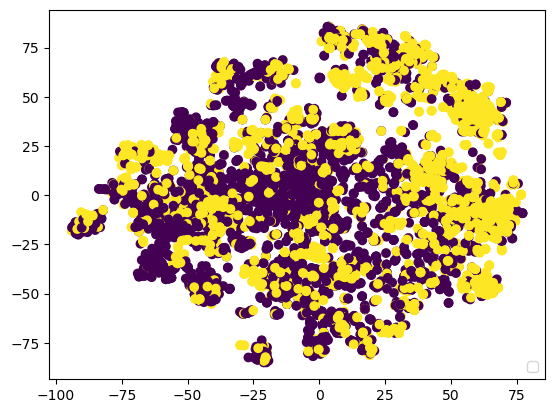

After Oversampling
Final_Ytrain
 0  
0.0    3217
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9642379679144385
Training MCC Score: 0.9280717156749614
Training F1 Score: 0.9640005105130263
Training AUC VALUE: 0.9950125479711763
Training kappa Score: 0.9280036440756391
Training Precision: 0.9674112046869279
Training Recall: 0.9548247199132635
Training Sensitivity: 0.9548247199132635
Training Specificity: 0.9723344731115946
Training CCR: 0.9642379679144385
Training PPV: 0.9674112046869279


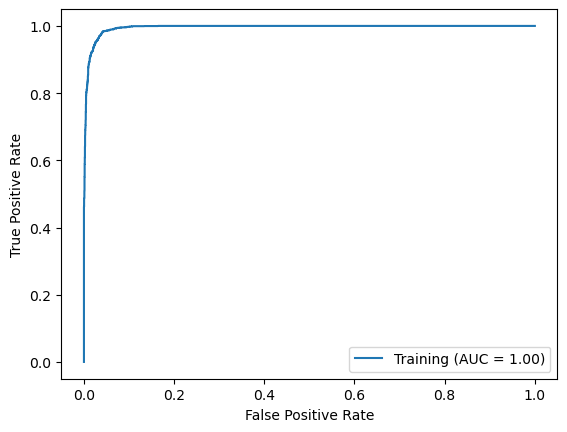

Testing Accuracy: 0.7341040462427746
Testing MCC Score: 0.45524279248153293
Testing F1 Score: 0.7254293939426613
Testing AUC VALUE: 0.7948938210016375
Testing kappa Score: 0.45247514534383704
Testing Precision: 0.7236842105263158
Testing Recall: 0.6353135313531353
Testing Sensitivity: 0.6353135313531353
Testing Specificity: 0.8110539845758354
Testing CCR: 0.7341040462427746
Testing PPV: 0.7236842105263158


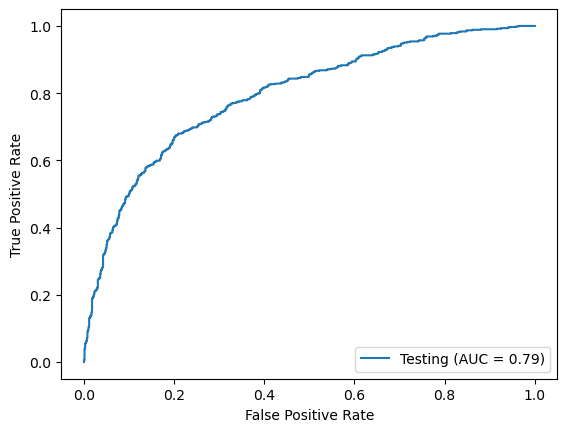

Fold # 16 Random Seed: 701
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-05 00:12:14,728:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:12:14,731:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:12:14,732:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 207
After filteration
Train shape
 (5535, 207) 
Test shape
 (1384, 207)
Before Oversampling
y_train_filtered
 0.0    3171
1.0    2364
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


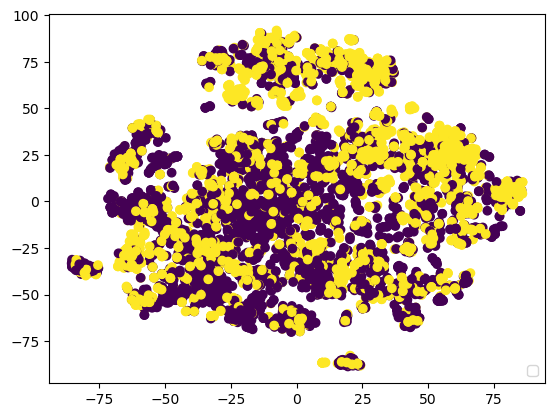

After Oversampling
Final_Ytrain
 0  
0.0    3171
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9957898282249916
Training MCC Score: 0.9915415929044317
Training F1 Score: 0.995770539954608
Training AUC VALUE: 0.9999605660122106
Training kappa Score: 0.9915410820782282
Training Precision: 0.9949458483754513
Training Recall: 0.9960245753523672
Training Sensitivity: 0.9960245753523672
Training Specificity: 0.9955849889624724
Training CCR: 0.9957898282249916
Training PPV: 0.9949458483754513


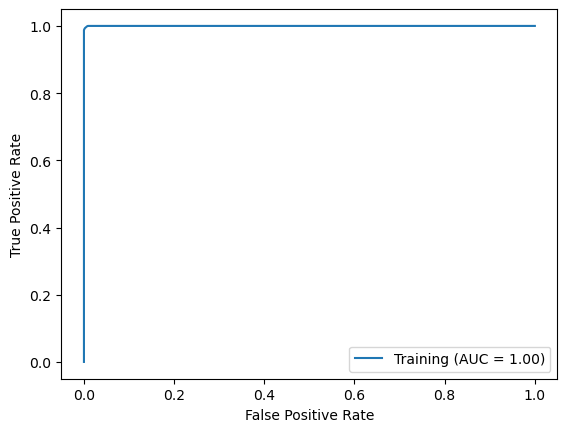

Testing Accuracy: 0.7398843930635838
Testing MCC Score: 0.451043634922258
Testing F1 Score: 0.7229679086701526
Testing AUC VALUE: 0.7942278519417476
Testing kappa Score: 0.44780380543684495
Testing Precision: 0.7074688796680498
Testing Recall: 0.6089285714285714
Testing Sensitivity: 0.6089285714285714
Testing Specificity: 0.8288834951456311
Testing CCR: 0.7398843930635838
Testing PPV: 0.7074688796680498


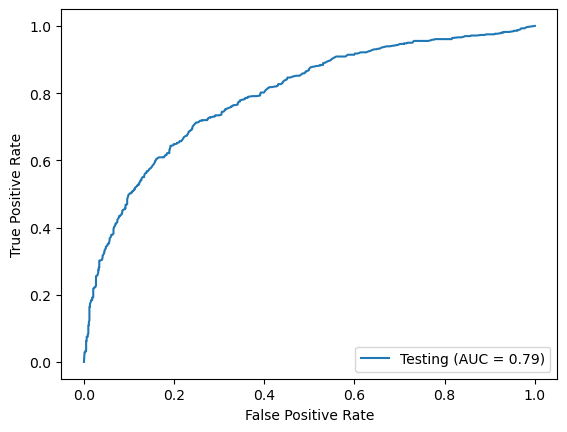

Fold # 17 Random Seed: 577
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-05 00:16:04,180:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:16:04,182:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:16:04,184:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 218
After filteration
Train shape
 (5535, 218) 
Test shape
 (1384, 218)
Before Oversampling
y_train_filtered
 0.0    3204
1.0    2331
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


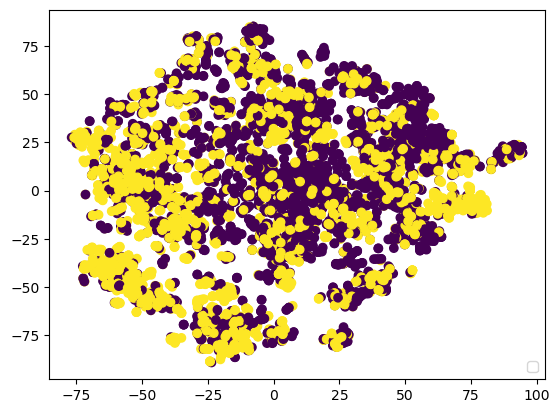

After Oversampling
Final_Ytrain
 0  
0.0    3204
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9959805727683805
Training MCC Score: 0.9919176813501548
Training F1 Score: 0.9959587277200416
Training AUC VALUE: 0.9999057579362983
Training kappa Score: 0.9919174563518165
Training Precision: 0.9960216998191682
Training Recall: 0.9953017708709794
Training Sensitivity: 0.9953017708709794
Training Specificity: 0.9965667915106118
Training CCR: 0.9959805727683805
Training PPV: 0.9960216998191682


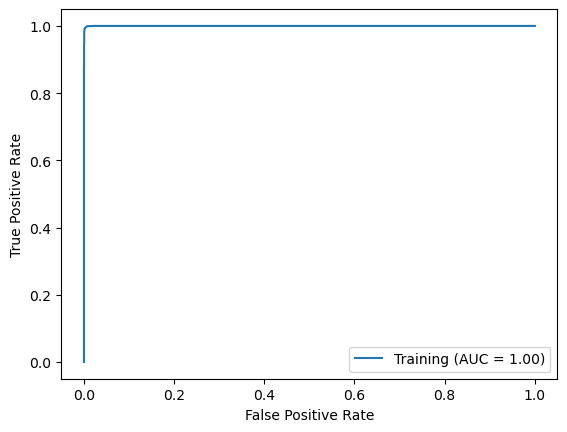

Testing Accuracy: 0.7297687861271677
Testing MCC Score: 0.44250855734899813
Testing F1 Score: 0.7194036970781157
Testing AUC VALUE: 0.7866171495087015
Testing kappa Score: 0.44021058505702626
Testing Precision: 0.7085714285714285
Testing Recall: 0.627318718381113
Testing Sensitivity: 0.627318718381113
Testing Specificity: 0.8065739570164349
Testing CCR: 0.7297687861271677
Testing PPV: 0.7085714285714285


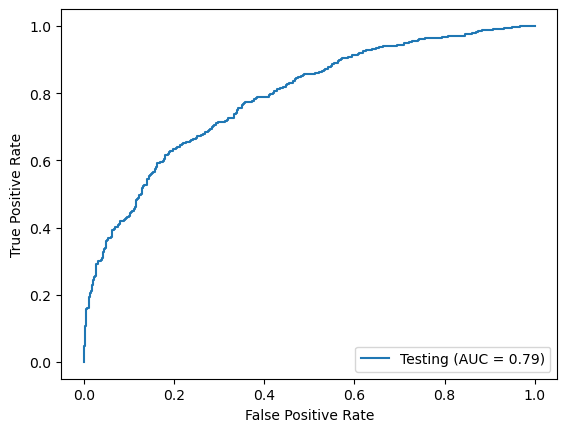

Fold # 18 Random Seed: 169
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-05 00:20:03,322:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:20:03,324:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:20:03,325:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 210
After filteration
Train shape
 (5535, 210) 
Test shape
 (1384, 210)
Before Oversampling
y_train_filtered
 0.0    3188
1.0    2347
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


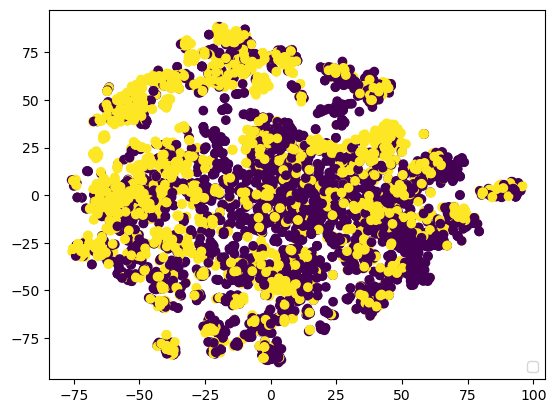

After Oversampling
Final_Ytrain
 0  
0.0    3188
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9947942905121746
Training MCC Score: 0.9895360895066909
Training F1 Score: 0.9947680164185742
Training AUC VALUE: 0.9998876569571745
Training kappa Score: 0.9895360331337127
Training Precision: 0.9945770065075922
Training Recall: 0.9942175641488977
Training Sensitivity: 0.9942175641488977
Training Specificity: 0.9952948557089084
Training CCR: 0.9947942905121746
Training PPV: 0.9945770065075922


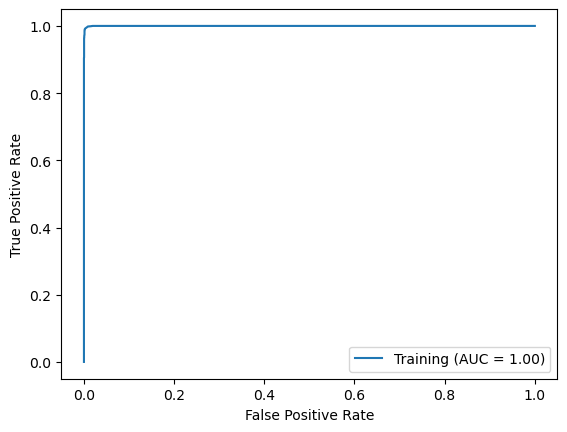

Testing Accuracy: 0.7369942196531792
Testing MCC Score: 0.45307845728865587
Testing F1 Score: 0.7252620442175757
Testing AUC VALUE: 0.8019399148267221
Testing kappa Score: 0.4514622200832319
Testing Precision: 0.7044145873320538
Testing Recall: 0.6360485268630849
Testing Sensitivity: 0.6360485268630849
Testing Specificity: 0.8091697645600991
Testing CCR: 0.7369942196531792
Testing PPV: 0.7044145873320538


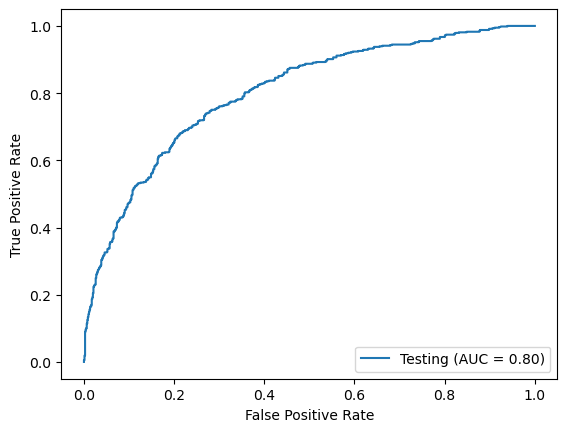

Fold # 19 Random Seed: 521
Before filteration
Train shape
 (5535, 3200) 
Test shape
 (1384, 3200)


2024-11-05 00:23:41,920:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:23:41,923:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:23:41,924:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 206
After filteration
Train shape
 (5535, 206) 
Test shape
 (1384, 206)
Before Oversampling
y_train_filtered
 0.0    3177
1.0    2358
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


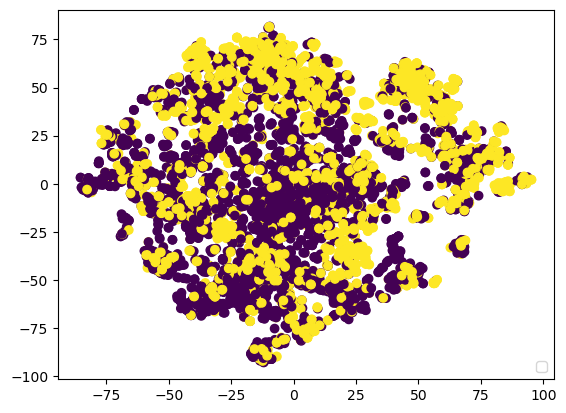

After Oversampling
Final_Ytrain
 0  
0.0    3177
1.0    2767
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9959623149394348
Training MCC Score: 0.9918860248586043
Training F1 Score: 0.9959430124293022
Training AUC VALUE: 0.9999641100387349
Training kappa Score: 0.9918860248586043
Training Precision: 0.9956631731116733
Training Recall: 0.9956631731116733
Training Sensitivity: 0.9956631731116733
Training Specificity: 0.996222851746931
Training CCR: 0.9959623149394348
Training PPV: 0.9956631731116733


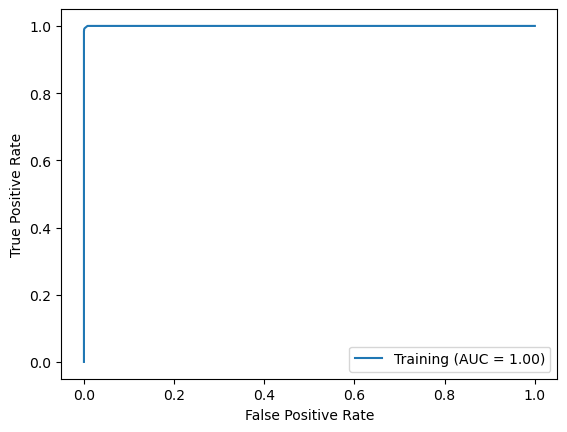

Testing Accuracy: 0.7507225433526011
Testing MCC Score: 0.4783506674209856
Testing F1 Score: 0.7379983110471673
Testing AUC VALUE: 0.8018717547755017
Testing kappa Score: 0.47680305055773486
Testing Precision: 0.7153996101364523
Testing Recall: 0.6484098939929329
Testing Sensitivity: 0.6484098939929329
Testing Specificity: 0.8215158924205379
Testing CCR: 0.7507225433526011
Testing PPV: 0.7153996101364523


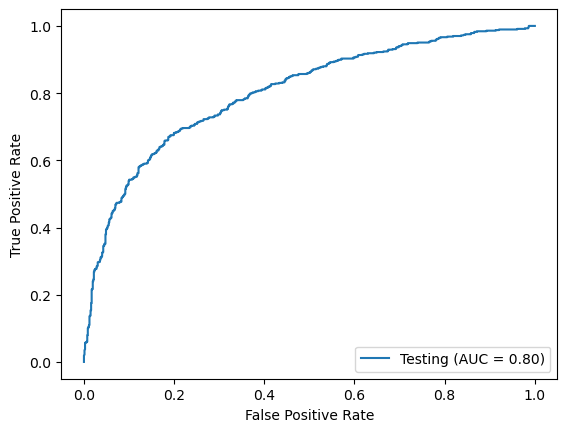

In [26]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.20, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered,0.5)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [27]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
4,0.763728,0.508704,0.752322,0.813372,0.505932,0.746562,0.657439,0.657439,0.839950,0.763728,0.746562
1,0.760838,0.508661,0.748461,0.808880,0.500676,0.777083,0.624791,0.624791,0.864041,0.760838,0.777083
10,0.756503,0.493096,0.743902,0.807038,0.489553,0.741483,0.640138,0.640138,0.839950,0.756503,0.741483
0,0.752890,0.490070,0.742501,0.806692,0.486700,0.743191,0.645270,0.645270,0.833333,0.752890,0.743191
7,0.752168,0.486693,0.739863,0.820904,0.482077,0.745968,0.630324,0.630324,0.841907,0.752168,0.745968
6,0.750723,0.483333,0.740320,0.823222,0.481557,0.725714,0.654639,0.654639,0.820449,0.750723,0.725714
19,0.750723,0.478351,0.737998,0.801872,0.476803,0.715400,0.648410,0.648410,0.821516,0.750723,0.715400
5,0.747832,0.477838,0.737932,0.809796,0.476546,0.718574,0.658076,0.658076,0.812968,0.747832,0.718574
2,0.748555,0.480134,0.736841,0.795044,0.475899,0.741036,0.630508,0.630508,0.836272,0.748555,0.741036
14,0.749277,0.476254,0.735763,0.802207,0.473156,0.726908,0.631763,0.631763,0.832306,0.749277,0.726908


In [28]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,True,0.0,None,gini,NaN,0.5,None,None,0.0,1,4,0.0,100,None,False,None,0,False
1,False,0.0,None,gini,110.0,log2,None,None,0.0,1,2,0.0,100,None,False,None,0,False
2,False,0.0,None,gini,100.0,log2,None,None,0.0,1,2,0.0,78,None,False,None,0,False
3,False,0.0,None,gini,20.0,0.5,None,None,0.0,4,11,0.0,100,None,False,None,0,False
4,False,0.0,None,gini,80.0,sqrt,None,None,0.0,1,13,0.0,56,None,False,None,0,False
5,False,0.0,None,gini,40.0,sqrt,None,None,0.0,3,4,0.0,89,None,False,None,0,False
6,False,0.0,None,gini,70.0,sqrt,None,None,0.0,1,25,0.0,100,None,False,None,0,False
7,False,0.0,None,gini,110.0,sqrt,None,None,0.0,1,12,0.0,78,None,False,None,0,False
8,False,0.0,None,gini,40.0,0.5,None,None,0.0,2,3,0.0,100,None,False,None,0,False
9,False,0.0,None,gini,70.0,sqrt,None,None,0.0,1,8,0.0,78,None,False,None,0,False


In [29]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[4])

209

In [30]:
#Save the feature names
pd.DataFrame(features[4]).to_csv('AID_1259407_features.csv',index=False)

In [31]:
#save the best parameters of the chosen model
with open('AID_1259407_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[4].keys())
    w.writeheader()
    w.writerow(Best_params[4])

In [32]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

"\n#Randomly split the data into testing and validation for each fold\ndef Test_valid_split(Set3,frac,seed):\n    Fraction=frac\n    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))\n    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]\n    Valid=Set3.T[Valid_index].T\n    print('Test set size:',len(Test),'\nValid set size:',len(Valid))\n    return Test,Valid\n"

In [33]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [34]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1259407_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['A1_15', 'A1_41', 'A1_43', 'A1_73', 'A1_84', 'A1_117', 'A1_125', 'A3_1', 'A3_6', 'A3_22', 'A3_25', 'A3_32', 'A3_33', 'A3_38', 'A3_49', 'A3_55', 'A3_62', 'A3_77', 'A3_79', 'A3_85', 'A3_91', 'A3_93', 'A3_102', 'A3_111', 'A3_115', 'A3_116', 'A3_125', 'A3_126', 'A4_31', 'A4_35', 'A4_52', 'A4_68', 'A4_84', 'A4_92', 'A4_118', 'A4_122', 'A5_3', 'A5_8', 'A5_10', 'A5_30', 'A5_36', 'A5_37', 'A5_38', 'A5_42', 'A5_49', 'A5_72', 'A5_77', 'A5_85', 'A5_89', 'A5_99', 'A5_101', 'A5_103', 'A5_107', 'B1_28', 'B2_0', 'B2_12', 'B2_41', 'B2_98', 'B2_102', 'B2_109', 'B2_122', 'B3_12', 'B3_20', 'B3_35', 'B3_60', 'B3_72', 'B3_116', 'B3_127', 'B4_16', 'B4_37', 'B4_117', 'B4_121', 'B5_4', 'B5_47', 'B5_53', 'B5_64', 'B5_116', 'C1_2', 'C1_7', 'C1_20', 'C1_28', 'C1_29', 'C1_34', 'C1_41', 'C1_43', 'C1_46', 'C1_51', 'C1_54', 'C1_55', 'C1_61', 'C1_62', 'C1_66', 'C1_74', 'C1_77', 'C1_79', 'C1_103', 'C1_121', 'C2_2', 'C2_21', 'C2_23', 'C2_43', 'C2_123', 'C4_12', 'C4_75', 'C5_1', 'C5_41', 'C5_63', 'C5_112', 'D1_1', 'D1_

In [35]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [36]:
y_train_prob

array([[0.9840824 , 0.0159176 ],
       [1.        , 0.        ],
       [0.90687533, 0.09312467],
       ...,
       [0.04957196, 0.95042804],
       [0.01444623, 0.98555377],
       [0.06712146, 0.93287854]])

2024-11-05 00:29:18,358:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:29:18,360:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:29:18,361:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 80.0, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 13, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 56, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


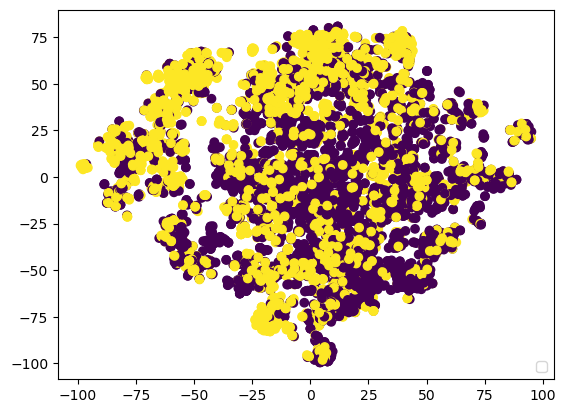

0  
0.0    3989
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9946294307196563
Training MCC Score: 0.9892057245909688
Training F1 Score: 0.9946010503885534
Training AUC VALUE: 0.9999154584619121
Training kappa Score: 0.9892021203451813
Training Precision: 0.9956509133082053
Training Recall: 0.9927724775946806
Training Sensitivity: 0.9927724775946806
Training Specificity: 0.9962396590624216
Training CCR: 0.9946294307196563
Training PPV: 0.9956509133082053


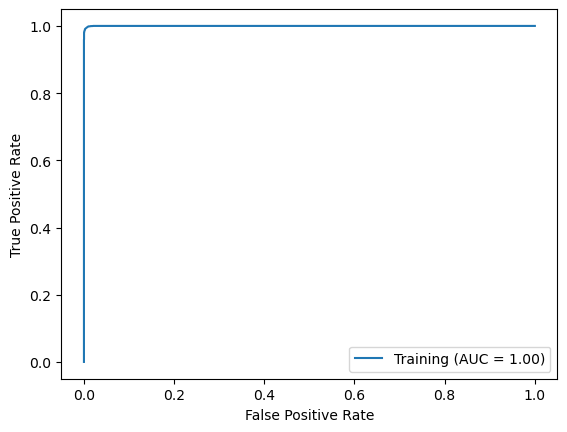

Testing Accuracy: 0.7490247074122237
Testing MCC Score: 0.48130443294655784
Testing F1 Score: 0.7393710148439654
Testing AUC VALUE: 0.8107715104765334
Testing kappa Score: 0.47962020833844654
Testing Precision: 0.7254237288135593
Testing Recall: 0.656441717791411
Testing Sensitivity: 0.656441717791411
Testing Specificity: 0.8171557562076749
Testing CCR: 0.7490247074122237
Testing PPV: 0.7254237288135593


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


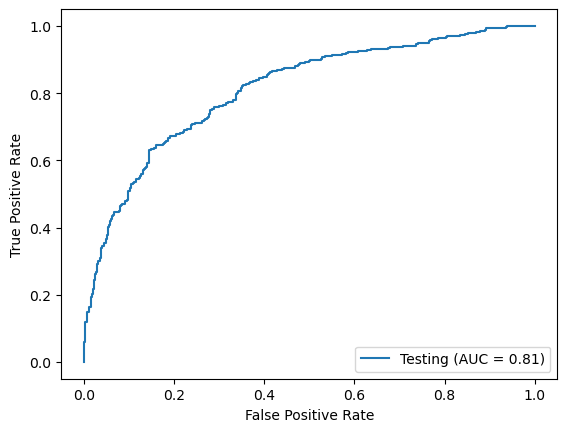

2024-11-05 00:29:40,854:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:29:40,856:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:29:40,857:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #2


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


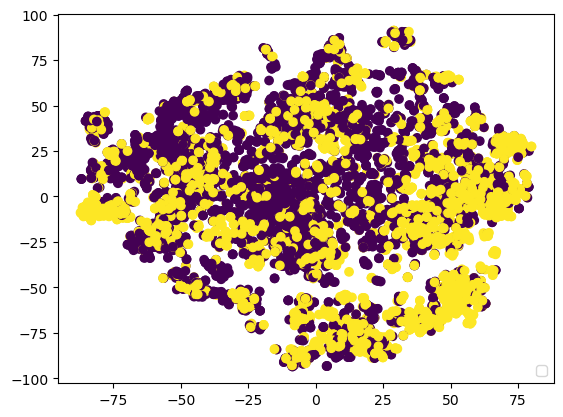

0  
0.0    3989
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9947636949516648
Training MCC Score: 0.9894739795493247
Training F1 Score: 0.9947365368245362
Training AUC VALUE: 0.999913139276984
Training kappa Score: 0.9894730784178682
Training Precision: 0.9950781702374059
Training Recall: 0.9936397802833189
Training Sensitivity: 0.9936397802833189
Training Specificity: 0.9957382802707445
Training CCR: 0.9947636949516648
Training PPV: 0.9950781702374059


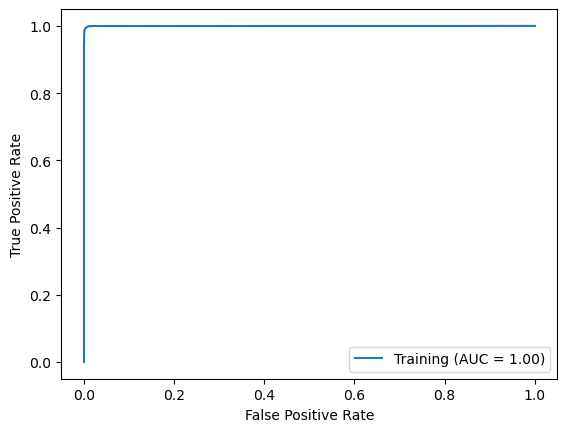

Testing Accuracy: 0.7373211963589077
Testing MCC Score: 0.4549127207738203
Testing F1 Score: 0.7211847735561874
Testing AUC VALUE: 0.8161344153775846
Testing kappa Score: 0.44695955568214185
Testing Precision: 0.7403100775193798
Testing Recall: 0.5858895705521472
Testing Sensitivity: 0.5858895705521472
Testing Specificity: 0.8487584650112867
Testing CCR: 0.7373211963589077
Testing PPV: 0.7403100775193798


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


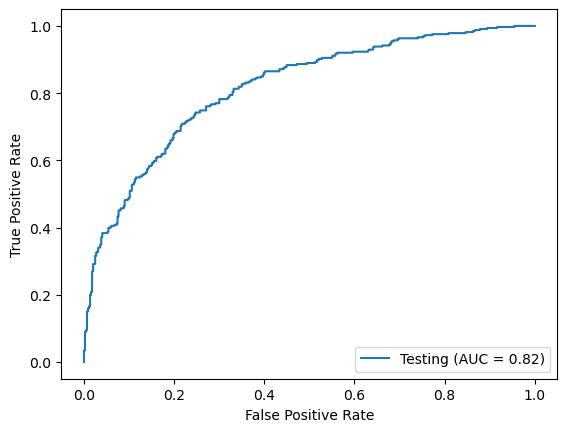

2024-11-05 00:30:03,421:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:30:03,423:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:30:03,424:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #3


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


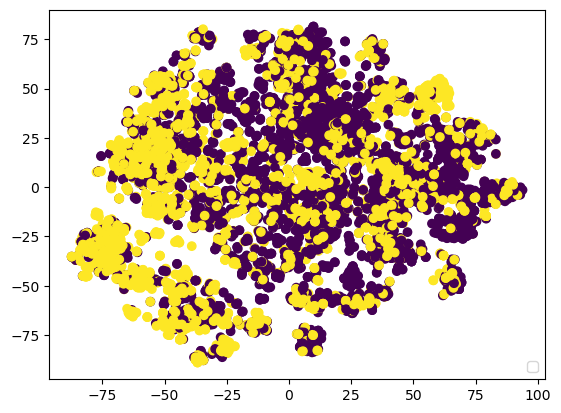

0  
0.0    3989
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9953007518796992
Training MCC Score: 0.9905545387910298
Training F1 Score: 0.9952771062945495
Training AUC VALUE: 0.9999364036007955
Training kappa Score: 0.9905542141293129
Training Precision: 0.9945118428653957
Training Recall: 0.9953743856605956
Training Sensitivity: 0.9953743856605956
Training Specificity: 0.9952369014790674
Training CCR: 0.9953007518796992
Training PPV: 0.9945118428653957


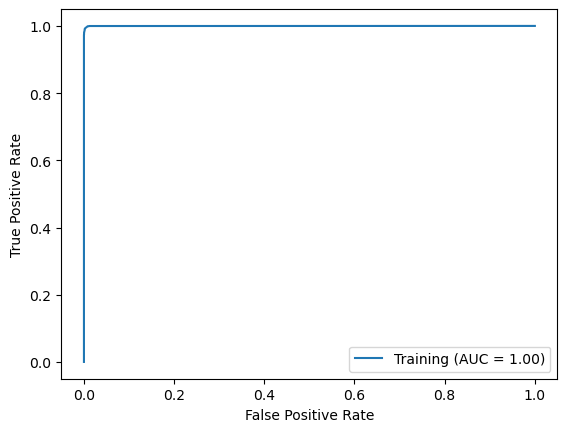

Testing Accuracy: 0.752925877763329
Testing MCC Score: 0.48914256611371315
Testing F1 Score: 0.7430174475868861
Testing AUC VALUE: 0.7985777396169453
Testing kappa Score: 0.48707777208293257
Testing Precision: 0.7328767123287672
Testing Recall: 0.656441717791411
Testing Sensitivity: 0.656441717791411
Testing Specificity: 0.8239277652370203
Testing CCR: 0.752925877763329
Testing PPV: 0.7328767123287672


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


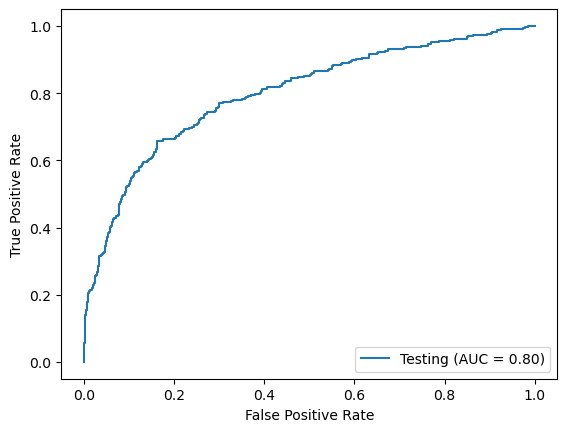

2024-11-05 00:30:25,997:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:30:25,999:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:30:26,001:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #4


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


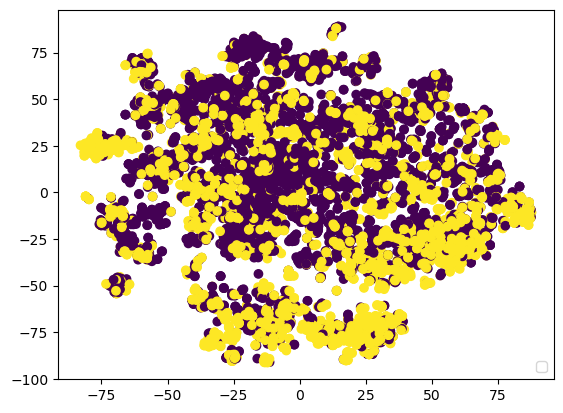

0  
0.0    3989
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9955692803437164
Training MCC Score: 0.991093271894412
Training F1 Score: 0.9955464727643555
Training AUC VALUE: 0.9999231045247226
Training kappa Score: 0.9910929469812474
Training Precision: 0.9956597222222222
Training Recall: 0.99479618386817
Training Sensitivity: 0.99479618386817
Training Specificity: 0.9962396590624216
Training CCR: 0.9955692803437164
Training PPV: 0.9956597222222222


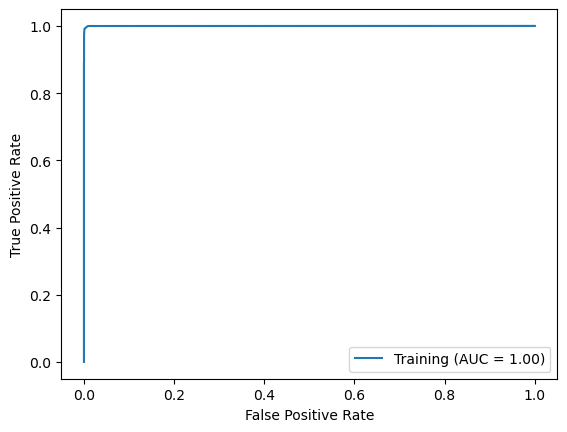

Testing Accuracy: 0.7321196358907672
Testing MCC Score: 0.4439336106332981
Testing F1 Score: 0.7174891571078013
Testing AUC VALUE: 0.7841681784819067
Testing kappa Score: 0.4383478106718667
Testing Precision: 0.7238805970149254
Testing Recall: 0.5950920245398773
Testing Sensitivity: 0.5950920245398773
Testing Specificity: 0.8329571106094809
Testing CCR: 0.7321196358907672
Testing PPV: 0.7238805970149254


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


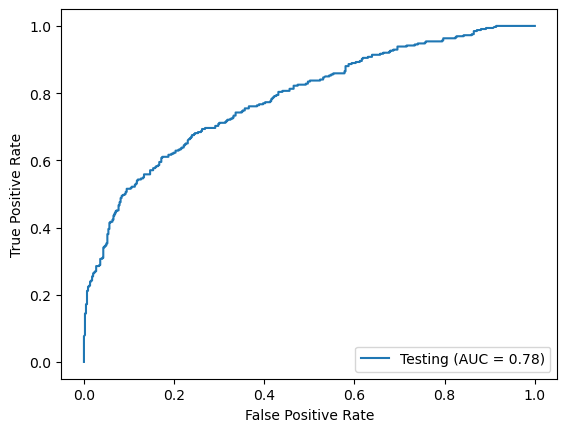

2024-11-05 00:30:48,714:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:30:48,716:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:30:48,717:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #5


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


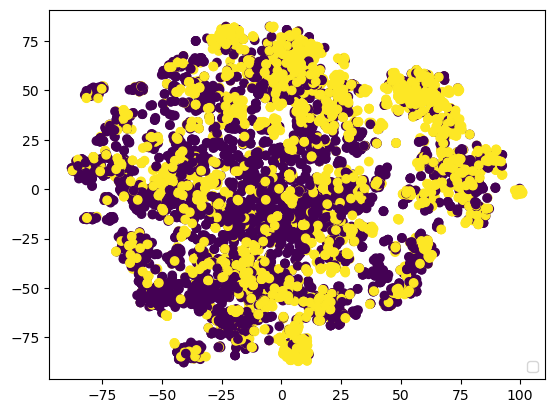

0  
0.0    3989
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9947636949516648
Training MCC Score: 0.9894775541537035
Training F1 Score: 0.9947357141737387
Training AUC VALUE: 0.9999264021157924
Training kappa Score: 0.9894714605945294
Training Precision: 0.9962275101567034
Training Recall: 0.9924833766984678
Training Sensitivity: 0.9924833766984678
Training Specificity: 0.9967410378540987
Training CCR: 0.9947636949516648
Training PPV: 0.9962275101567034


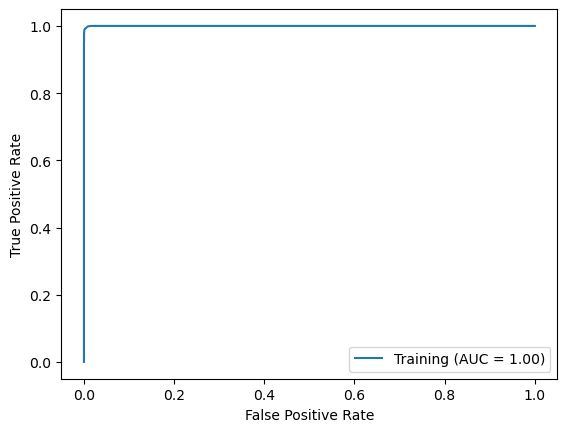

Testing Accuracy: 0.7308192457737321
Testing MCC Score: 0.44293835420741123
Testing F1 Score: 0.7198749861418337
Testing AUC VALUE: 0.8039718040687449
Testing kappa Score: 0.4409551135944596
Testing Precision: 0.7044673539518901
Testing Recall: 0.6288343558282209
Testing Sensitivity: 0.6288343558282209
Testing Specificity: 0.8058690744920993
Testing CCR: 0.7308192457737321
Testing PPV: 0.7044673539518901


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


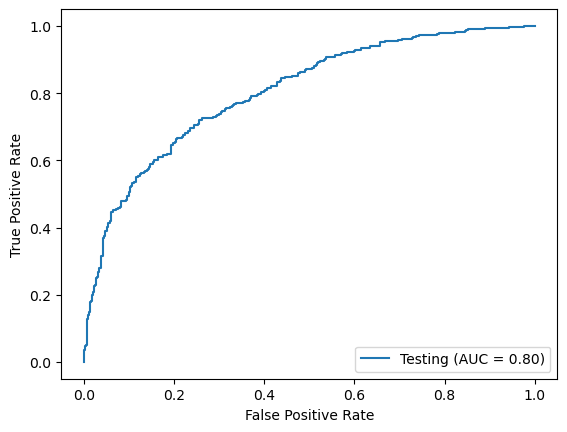

2024-11-05 00:31:11,571:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:31:11,573:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:31:11,574:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #6


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


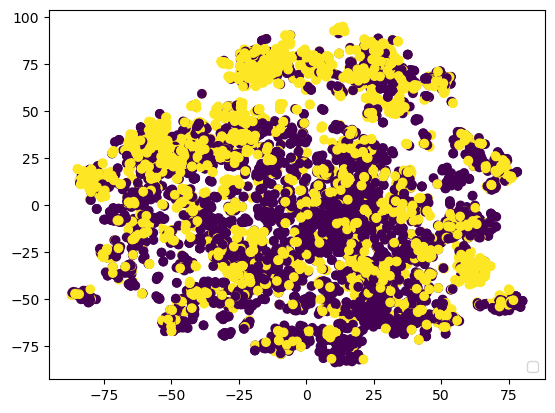

0  
0.0    3989
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9943609022556391
Training MCC Score: 0.9886641091953674
Training F1 Score: 0.9943317648394163
Training AUC VALUE: 0.9999099141604432
Training kappa Score: 0.9886635329655065
Training Precision: 0.9945007235890014
Training Recall: 0.9933506793871061
Training Sensitivity: 0.9933506793871061
Training Specificity: 0.9952369014790674
Training CCR: 0.9943609022556391
Training PPV: 0.9945007235890014


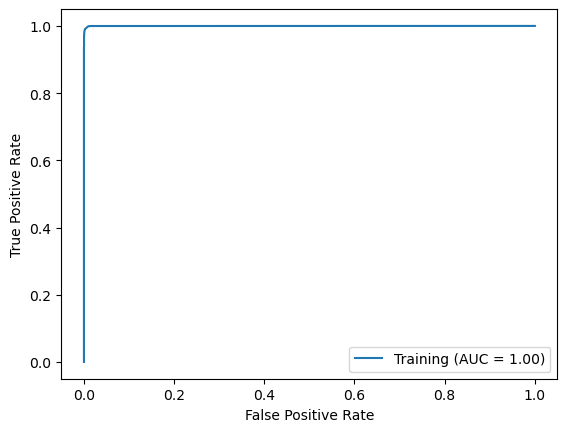

Testing Accuracy: 0.7672301690507152
Testing MCC Score: 0.5184550286921575
Testing F1 Score: 0.7564203518917321
Testing AUC VALUE: 0.8205244498608207
Testing kappa Score: 0.5145801227911175
Testing Precision: 0.7615658362989324
Testing Recall: 0.656441717791411
Testing Sensitivity: 0.656441717791411
Testing Specificity: 0.8487584650112867
Testing CCR: 0.7672301690507152
Testing PPV: 0.7615658362989324


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


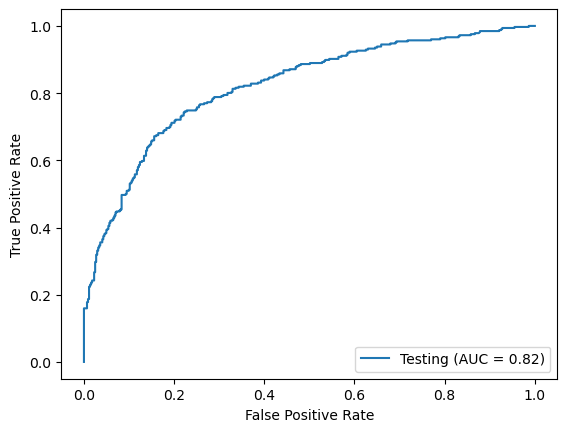

2024-11-05 00:31:34,645:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:31:34,647:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:31:34,649:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #7


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


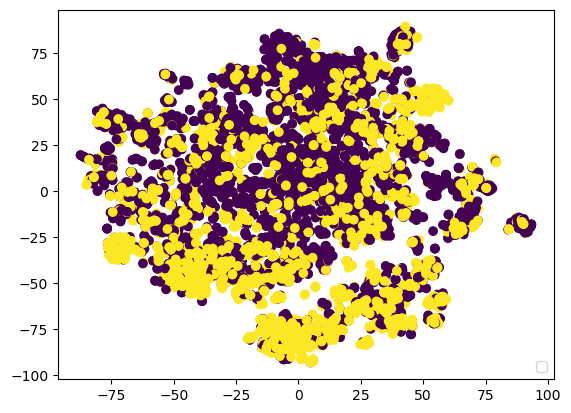

0  
0.0    3988
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9955686853766618
Training MCC Score: 0.991093811117522
Training F1 Score: 0.9955454362296218
Training AUC VALUE: 0.9999476602690407
Training kappa Score: 0.9910908855398972
Training Precision: 0.9965217391304347
Training Recall: 0.9939288811795317
Training Sensitivity: 0.9939288811795317
Training Specificity: 0.9969909729187563
Training CCR: 0.9955686853766618
Training PPV: 0.9965217391304347


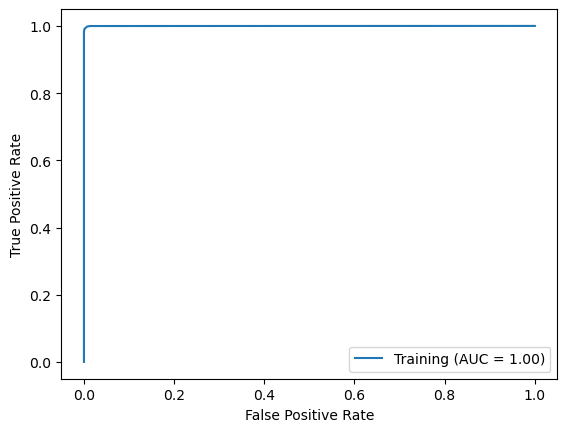

Testing Accuracy: 0.7594278283485045
Testing MCC Score: 0.5020859245440946
Testing F1 Score: 0.7493768112112322
Testing AUC VALUE: 0.814948024948025
Testing kappa Score: 0.4998330022676535
Testing Precision: 0.7413793103448276
Testing Recall: 0.6615384615384615
Testing Sensitivity: 0.6615384615384615
Testing Specificity: 0.831081081081081
Testing CCR: 0.7594278283485045
Testing PPV: 0.7413793103448276


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


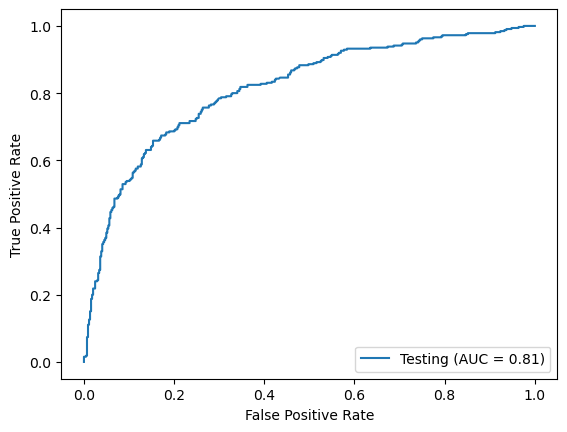

2024-11-05 00:31:57,549:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:31:57,551:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:31:57,553:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #8


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


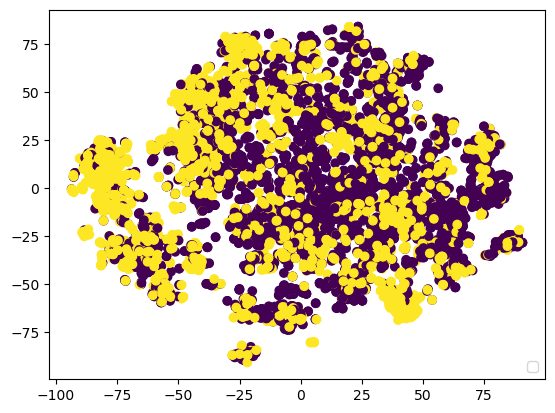

0  
0.0    3988
1.0    3459
Name: count, dtype: int64
Training Accuracy: 0.9953001208540352
Training MCC Score: 0.990552351158803
Training F1 Score: 0.9952760124031295
Training AUC VALUE: 0.9999308782084908
Training kappa Score: 0.9905520263473934
Training Precision: 0.9953703703703703
Training Recall: 0.9945070829719572
Training Sensitivity: 0.9945070829719572
Training Specificity: 0.995987963891675
Training CCR: 0.9953001208540352
Training PPV: 0.9953703703703703


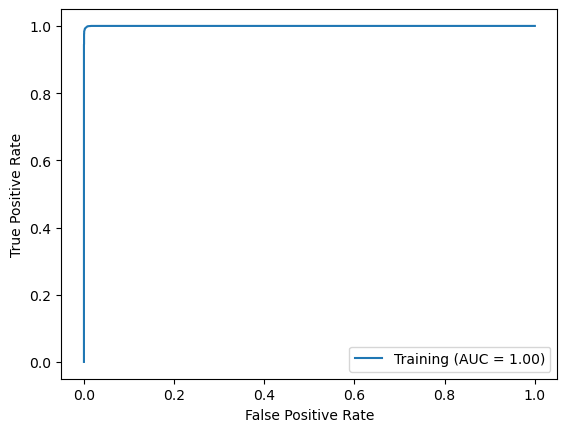

Testing Accuracy: 0.7438231469440832
Testing MCC Score: 0.4693016384071074
Testing F1 Score: 0.7328283585379833
Testing AUC VALUE: 0.8110395010395011
Testing kappa Score: 0.4669437045429755
Testing Precision: 0.7222222222222222
Testing Recall: 0.64
Testing Sensitivity: 0.64
Testing Specificity: 0.8198198198198198
Testing CCR: 0.7438231469440832
Testing PPV: 0.7222222222222222


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


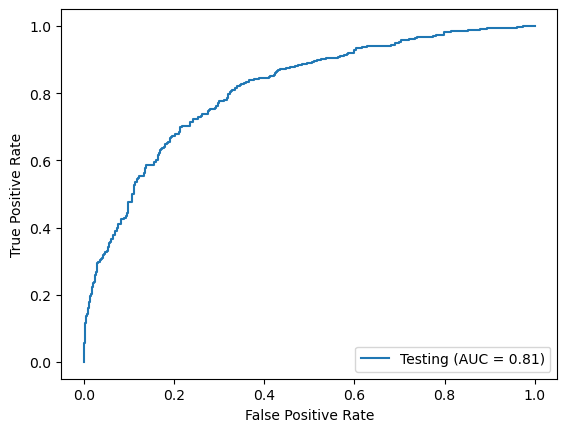

2024-11-05 00:32:20,920:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:32:20,922:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:32:20,923:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #9


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


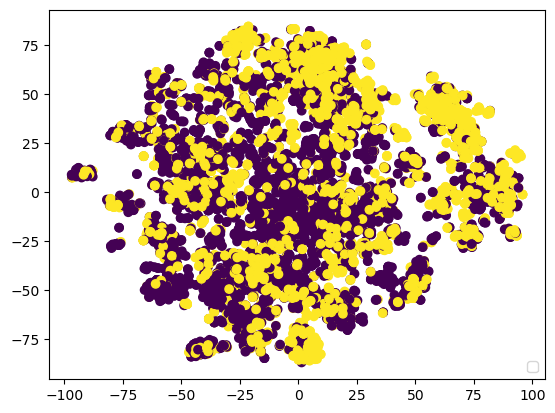

0  
0.0    3989
1.0    3460
Name: count, dtype: int64
Training Accuracy: 0.9943616592831253
Training MCC Score: 0.9886687572095719
Training F1 Score: 0.9943337270976862
Training AUC VALUE: 0.999902006529517
Training kappa Score: 0.9886674615842748
Training Precision: 0.9930755914598961
Training Recall: 0.9947976878612717
Training Sensitivity: 0.9947976878612717
Training Specificity: 0.9939834544998747
Training CCR: 0.9943616592831253
Training PPV: 0.9930755914598961


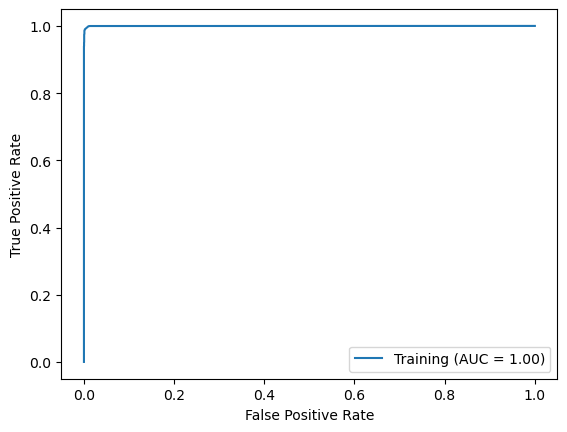

Testing Accuracy: 0.7604166666666666
Testing MCC Score: 0.5043003535978565
Testing F1 Score: 0.7503797861892078
Testing AUC VALUE: 0.8157249522486543
Testing kappa Score: 0.5018998808609033
Testing Precision: 0.7439446366782007
Testing Recall: 0.6615384615384615
Testing Sensitivity: 0.6615384615384615
Testing Specificity: 0.8329571106094809
Testing CCR: 0.7604166666666666
Testing PPV: 0.7439446366782007


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


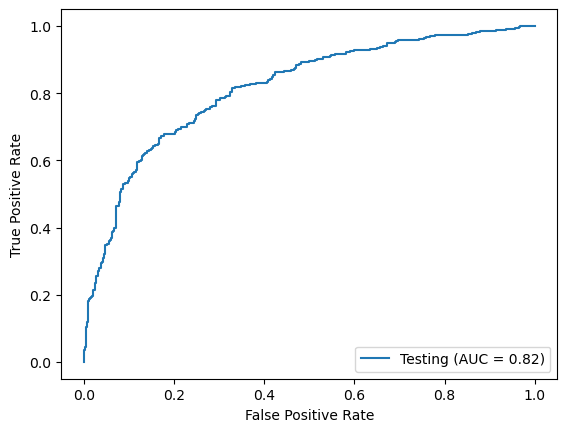

2024-11-05 00:32:44,327:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:32:44,328:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:32:44,330:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #10


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_92960\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


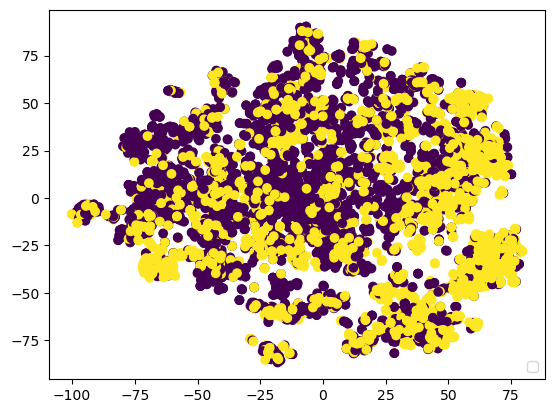

0  
0.0    3989
1.0    3460
Name: count, dtype: int64
Training Accuracy: 0.9944959054906699
Training MCC Score: 0.9889362923318519
Training F1 Score: 0.9944672588312692
Training AUC VALUE: 0.9999033469207952
Training kappa Score: 0.9889345274850955
Training Precision: 0.9950767448595425
Training Recall: 0.9930635838150289
Training Sensitivity: 0.9930635838150289
Training Specificity: 0.9957382802707445
Training CCR: 0.9944959054906699
Training PPV: 0.9950767448595425


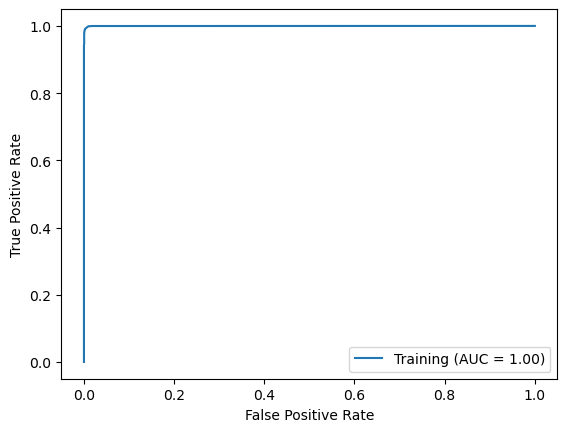

Testing Accuracy: 0.734375
Testing MCC Score: 0.4493051191188455
Testing F1 Score: 0.7223230490018149
Testing AUC VALUE: 0.7836916131272791
Testing kappa Score: 0.446376954988445
Testing Precision: 0.7137809187279152
Testing Recall: 0.6215384615384615
Testing Sensitivity: 0.6215384615384615
Testing Specificity: 0.8171557562076749
Testing CCR: 0.734375
Testing PPV: 0.7137809187279152


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


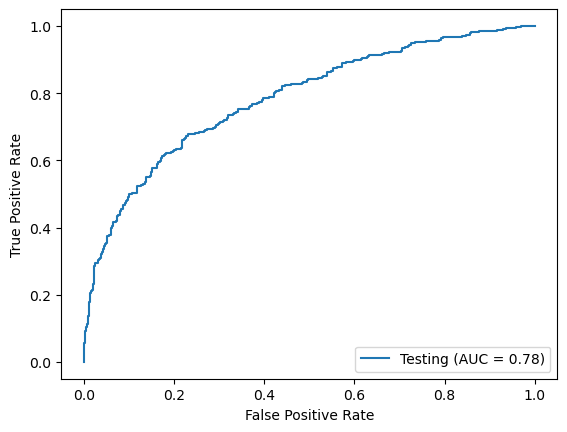

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [37]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

Parameters = pd.DataFrame.from_dict(Best_params).iloc[4].to_dict()
print(Parameters)
# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y), 0.5)
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [38]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
5,0.767230,0.518455,0.756420,0.820524,0.514580,0.761566,0.656442,0.656442,0.848758,0.767230,0.761566
8,0.760417,0.504300,0.750380,0.815725,0.501900,0.743945,0.661538,0.661538,0.832957,0.760417,0.743945
6,0.759428,0.502086,0.749377,0.814948,0.499833,0.741379,0.661538,0.661538,0.831081,0.759428,0.741379
2,0.752926,0.489143,0.743017,0.798578,0.487078,0.732877,0.656442,0.656442,0.823928,0.752926,0.732877
0,0.749025,0.481304,0.739371,0.810772,0.479620,0.725424,0.656442,0.656442,0.817156,0.749025,0.725424
7,0.743823,0.469302,0.732828,0.811040,0.466944,0.722222,0.640000,0.640000,0.819820,0.743823,0.722222
1,0.737321,0.454913,0.721185,0.816134,0.446960,0.740310,0.585890,0.585890,0.848758,0.737321,0.740310
9,0.734375,0.449305,0.722323,0.783692,0.446377,0.713781,0.621538,0.621538,0.817156,0.734375,0.713781
4,0.730819,0.442938,0.719875,0.803972,0.440955,0.704467,0.628834,0.628834,0.805869,0.730819,0.704467
3,0.732120,0.443934,0.717489,0.784168,0.438348,0.723881,0.595092,0.595092,0.832957,0.732120,0.723881


<Axes: >

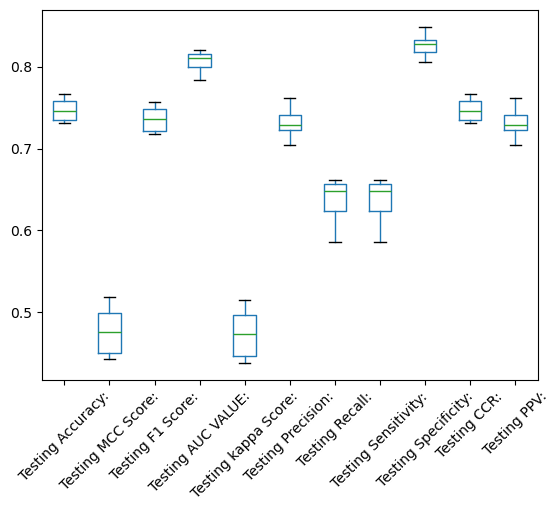

In [39]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [40]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.749025,0.481304,0.739371,0.810772,0.479620,0.725424,0.656442,0.656442,0.817156,0.749025,0.725424
1,0.737321,0.454913,0.721185,0.816134,0.446960,0.740310,0.585890,0.585890,0.848758,0.737321,0.740310
2,0.752926,0.489143,0.743017,0.798578,0.487078,0.732877,0.656442,0.656442,0.823928,0.752926,0.732877
3,0.732120,0.443934,0.717489,0.784168,0.438348,0.723881,0.595092,0.595092,0.832957,0.732120,0.723881
4,0.730819,0.442938,0.719875,0.803972,0.440955,0.704467,0.628834,0.628834,0.805869,0.730819,0.704467
5,0.767230,0.518455,0.756420,0.820524,0.514580,0.761566,0.656442,0.656442,0.848758,0.767230,0.761566
6,0.759428,0.502086,0.749377,0.814948,0.499833,0.741379,0.661538,0.661538,0.831081,0.759428,0.741379
7,0.743823,0.469302,0.732828,0.811040,0.466944,0.722222,0.640000,0.640000,0.819820,0.743823,0.722222
8,0.760417,0.504300,0.750380,0.815725,0.501900,0.743945,0.661538,0.661538,0.832957,0.760417,0.743945
9,0.734375,0.449305,0.722323,0.783692,0.446377,0.713781,0.621538,0.621538,0.817156,0.734375,0.713781


In [41]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,-0.100800,0.096205,-0.101666,0.013622,0.045533,0.103638,0.100818,-0.085028,-0.027932,-0.060816,...,-0.126018,0.077215,-0.060099,0.000407,0.024521,-0.008713,0.052200,0.073152,-0.119952,0.076824
1,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,-0.029744,...,-0.012364,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740
2,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,0.058144,...,-0.026042,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499
3,0.082662,0.102963,0.096697,0.088996,0.102963,0.102961,0.098535,-0.102962,-0.102963,-0.087077,...,0.105257,0.040878,-0.093784,0.035378,-0.097579,0.009945,-0.008528,-0.013349,-0.078162,-0.111090
4,-0.096225,0.070796,0.064892,0.091473,-0.093061,0.077097,0.088396,-0.096911,-0.096889,0.095496,...,-0.104367,-0.055854,0.063072,0.029263,0.087089,0.052258,0.060351,-0.020115,0.083724,0.063224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7683,0.050551,0.102426,-0.099660,-0.098485,-0.107214,0.085093,0.108473,-0.102509,-0.107991,0.007925,...,-0.043182,-0.116790,-0.091026,-0.002655,-0.099866,-0.116036,-0.018843,-0.117772,-0.121155,0.066548
7684,0.073188,0.105431,-0.040435,0.075106,-0.086526,0.105199,0.103438,-0.105303,-0.103506,0.003357,...,-0.078037,-0.018075,0.095330,0.078552,-0.063007,-0.046275,-0.035554,-0.132552,0.090953,-0.086539
7685,-0.102254,-0.094302,-0.093187,-0.067410,-0.060660,-0.104566,-0.104565,0.094424,-0.102475,0.087305,...,-0.006239,0.043983,-0.046289,-0.053898,0.131852,0.116559,0.021459,0.119129,0.068994,-0.033954
7686,0.095105,0.095757,0.095757,0.093176,0.092714,0.095747,0.095731,-0.095757,-0.095755,0.095743,...,-0.127033,-0.074568,-0.122869,0.049453,-0.041374,-0.121854,0.130615,0.103142,0.044125,0.107396


In [42]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,A1_15,A1_41,A1_43,A1_73,A1_84,A1_117,A1_125,A3_1,A3_6,A3_22,...,E4_114,E4_115,E4_116,E4_117,E4_125,E5_6,E5_8,E5_33,E5_64,E5_117
0,-0.001260,0.091894,-0.066789,0.098337,0.104054,0.039225,0.100717,0.098489,-0.098967,-0.070834,...,-0.085608,0.011995,-0.006036,0.102261,-0.100890,0.059893,-0.118004,0.117628,-0.032211,0.026115
1,-0.095357,0.089097,0.041819,0.096365,0.096480,0.008305,0.085528,0.098708,0.102282,0.101359,...,0.092934,0.071426,-0.129429,0.070241,-0.115071,-0.014971,-0.119562,0.028673,-0.109246,0.126525
2,-0.091460,0.069262,-0.081728,0.099203,0.099325,0.005228,0.053900,0.111468,-0.109875,-0.109869,...,0.064732,0.039603,-0.048368,-0.052314,0.011509,-0.050650,-0.073611,0.135791,-0.068717,0.100837
3,0.102950,0.094081,-0.102710,-0.045036,0.102616,-0.102900,-0.102963,0.104072,-0.104064,0.104071,...,0.010903,0.029632,0.080693,-0.066877,0.022375,0.124771,-0.088883,0.134413,-0.079405,0.085505
4,-0.096673,-0.091828,0.096050,0.096344,0.091485,-0.094610,0.096765,0.094162,0.094195,0.094186,...,-0.089099,0.104638,-0.111684,0.111692,-0.097193,0.129420,-0.133363,0.148037,0.096464,0.129279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7683,-0.105112,0.064258,-0.013680,0.072076,0.106118,-0.087171,-0.006165,-0.097055,0.096809,0.094383,...,-0.002868,-0.050377,-0.099376,0.098538,0.006630,0.006657,-0.030507,-0.086733,-0.113043,0.048217
7684,-0.100760,-0.070071,-0.083070,0.102926,0.105533,-0.096536,-0.103424,-0.095113,-0.095151,-0.094995,...,-0.141230,0.107195,-0.115706,-0.083258,0.054531,-0.048966,0.042536,-0.081011,-0.084997,-0.078319
7685,-0.098732,-0.042552,0.104647,-0.104175,-0.099275,-0.104040,0.102232,-0.106302,-0.082336,-0.046586,...,-0.099262,0.095504,-0.038586,-0.096446,0.031692,0.074225,-0.085629,0.095509,0.064426,0.121379
7686,-0.076170,-0.095477,-0.095426,0.095400,0.095743,0.062699,-0.095750,0.096988,0.096642,0.096937,...,-0.037041,-0.037191,0.113149,-0.109092,0.101640,-0.072618,0.039227,-0.003804,-0.078824,0.132486


In [43]:
Y = Data['status']

In [44]:
#Fitting the model on whole data
fitted = models_1[5].fit(TRAIN,Y)
fitted

RandomForestClassifier(bootstrap=False, max_depth=80.0, max_features='sqrt',
                       min_samples_split=13, n_estimators=56)

In [45]:
#Save the final model
joblib.dump(fitted, 'AID_1259407_RF.pkl')

['AID_1259407_RF.pkl']

In [46]:
import joblib
import pandas as pd

class model_AID_1259407:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1259407_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1259407_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1259407(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1259407(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1259407_0'] = None
    Feature_data['AID_1259407_1'] = None
    Feature_data['AID_1259407_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259407_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259407_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259407_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
